# HCT-Microbiome: A Longitudinal Benchmark for Gut Microbiome Surveillance
**Paper Accepted in IEEE ICKG 2026 Applied Track**

*Note for Reviewers: This notebook was executed and validated on a Google Colab environment utilizing a TPU: v5e-1 TPU. Minor floating-point variations may occur if executed on differing hardware architectures. Random seeds are globally fixed via `enable_op_determinism()` to maximize reproducibility.*

# Hard-coded versions to guarantee long-term reproducibility
**!pip install tensorflow==2.20.0 xgboost==3.2.0 scikit-learn==1.6.1 seaborn==0.13.2**


In [ ]:
# ============================================================
# HCT-Microbiome Benchmark – FINAL CORRECTED VERSION
# FULL PIPELINE + LABEL + MODELS + CI + PLOTS
# ============================================================

# ===============================
# 1. INSTALL
# ===============================
!pip install tensorflow==2.20.0 xgboost==3.2.0 scikit-learn==1.6.1 seaborn==0.13.2


# ===============================
# 2. IMPORTS
# ===============================
import os, random, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

from scipy.stats import entropy
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    f1_score, precision_score, recall_score,
    precision_recall_curve, roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import tensorflow as tf
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import AUC

# Configure Matplotlib for academic LaTeX-style rendering without requiring local LaTeX
plt.rcParams.update({
    "text.usetex": False,
    "mathtext.fontset": "cm",
    "font.family": "serif",
    "font.size": 10
})

def set_global_seed(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    tf.keras.utils.set_random_seed(seed)
    tf.config.experimental.enable_op_determinism()

set_global_seed(42)
print("Global seeds set and TensorFlow operation determinism enabled.")

In [7]:
# ===============================
# 3. DATA LOADING
# ===============================
# 1. Automatic Google Colab Environment Setup
if 'google.colab' in sys.modules:
    print("Google Colab detected. Cloning anonymous repository for data access...")
    !git clone https://github.com/mlresearcher81/HCT-Microbiome-Benchmark.git
    %cd HCT-Microbiome-Benchmark
else:
    print("Local environment detected.")

# 2. Local Data Loading
# Ensure the CSV is located in the data/ folder of your repository
data_path = "./data/HCT_Microbiome_Benchmark.csv"

if not os.path.exists(data_path):
    raise FileNotFoundError(f"Dataset not found at {data_path}. Please ensure the repository cloned correctly.")

df_raw = pd.read_csv(data_path, dtype={"PatientID": str})
print(f"Loaded Raw Data: {df_raw.shape[0]:,} taxonomic records.")
print(f"Unique Patients: {df_raw['PatientID'].nunique():,}")

Google Colab detected. Cloning anonymous repository for data access...
Cloning into 'HCT-Microbiome-Benchmark'...
remote: Enumerating objects: 118, done.
remote: Counting objects: 100% (118/118), done.
remote: Compressing objects: 100% (106/106), done.
remote: Total 118 (delta 55), reused 24 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (118/118), 14.71 MiB | 7.29 MiB/s, done.
Resolving deltas: 100% (55/55), done.
/content/HCT-Microbiome-Benchmark/HCT-Microbiome-Benchmark
Loaded Raw Data: 514,246 taxonomic records.
Unique Patients: 1,870


In [8]:
# ===============================
# 4. DATA PIVOTING
# ===============================
TARGET_COL = 'Dysbiosis_Label'
ABUNDANCE_COL = 'RelativeAbundance'

if TARGET_COL not in df_raw.columns:
    print(f"Warning: {TARGET_COL} not found. Defaulting to 'Disease' as the label.")
    TARGET_COL = 'Disease'

index_cols = ['PatientID', 'SampleID', 'DayRelativeToNearestHCT', TARGET_COL]
index_cols = [c for c in index_cols if c in df_raw.columns]

print("Pivoting data from Long to Wide format...")
df = df_raw.pivot_table(
    index=index_cols,
    columns='Genus',
    values=ABUNDANCE_COL,
    fill_value=0
).reset_index()

metadata_cols = index_cols
feature_cols = [col for col in df.columns if col not in metadata_cols]
print(f"Pivot complete! Detected {len(feature_cols)} unique taxonomic features.")

Pivoting data from Long to Wide format...
Pivot complete! Detected 412 unique taxonomic features.


In [9]:
# ==============================================================================
# 5. VARIANCE FILTRATION (NO DOUBLE LOGGING)
# ==============================================================================
# Convert to float and fill NAs to prevent math errors
df[feature_cols] = df[feature_cols].astype(float).fillna(0).clip(lower=0)

# We temporarily log-transform just to find the active features safely
temp_log = np.log1p(df[feature_cols])
print("Applying variance filtration (\u03C3^2 > 10^-6)...")
variances = temp_log.var()
active_features = variances[variances > 1e-6].index.tolist()

# Keep the RAW data in the dataframe for accurate dysbiosis calculation later
df = df[metadata_cols + active_features]
df = df.rename(columns={TARGET_COL: 'Dysbiosis_Label'})

print(f"Features reduced from {len(feature_cols)} to {len(active_features)} active ASVs.")

Applying variance filtration (σ^2 > 10^-6)...
Features reduced from 412 to 119 active ASVs.


In [10]:
# ==============================================================================
# 6. STRICT PATIENT-LEVEL SPLITTING (GROUP SHUFFLE SPLIT)
# ==============================================================================
print("\nSplitting data at the PATIENT level...")
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df['PatientID']))

df_train_temp = df.iloc[train_idx].reset_index(drop=True)
df_test = df.iloc[test_idx].reset_index(drop=True)

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.125, random_state=42) # 10% of total
train_final_idx, val_idx = next(gss_val.split(df_train_temp, groups=df_train_temp['PatientID']))

df_train = df_train_temp.iloc[train_final_idx].reset_index(drop=True)
df_val = df_train_temp.iloc[val_idx].reset_index(drop=True)

print(f"Unique Patients in Train: {df_train['PatientID'].nunique()}")
print(f"Unique Patients in Val:   {df_val['PatientID'].nunique()}")
print(f"Unique Patients in Test:  {df_test['PatientID'].nunique()}")


Splitting data at the PATIENT level...
Unique Patients in Train: 1309
Unique Patients in Val:   187
Unique Patients in Test:  374


In [11]:
from sklearn.preprocessing import MinMaxScaler
# ==============================================================================
# 7. SEQUENCE GENERATION & LABELING (THE BENCHMARK CHALLENGE)
# ==============================================================================
def check_benchmark_dysbiosis(microbiome_window_raw):
    """Calculates Dysbiosis based on Pathogen Domination AND Ecological Collapse."""
    for row in microbiome_window_raw:
        total = row.sum()
        if total == 0: continue
        rel_abund = row / total

        # 1. Pathogen Domination
        is_dominated = rel_abund.max() >= 0.30

        # 2. Ecological Collapse
        shannon_div = entropy(rel_abund, base=np.e)
        is_collapsed = shannon_div < 1.5

        if is_dominated and is_collapsed:
            return 1 # Dysbiosis Event
    return 0 # Stable

def build_benchmark_sequences(data_split, active_feat_cols, scaler, fit_scaler=False, obs_len=5, target_len=2):
    """
    Generates X (5 days) and Y (Next 2 days).
    Calculates Y on RAW data, then safely applies log1p and MinMax to X.
    """
    X_sequences_raw = []
    y_labels = []

    for pid, group in data_split.groupby('PatientID'):
        group = group.sort_values('DayRelativeToNearestHCT')
        raw_values = group[active_feat_cols].values.astype(float)

        total_window = obs_len + target_len

        if len(raw_values) >= total_window:
            for i in range(len(raw_values) - total_window + 1):
                # Target Window (Y) - Evaluated on RAW abundances
                window_y_raw = raw_values[i + obs_len : i + total_window]
                label = check_benchmark_dysbiosis(window_y_raw)

                # Observation Window (X)
                seq_x_raw = raw_values[i : i + obs_len]

                X_sequences_raw.append(seq_x_raw)
                y_labels.append(label)

    X_sequences_raw = np.array(X_sequences_raw)
    y_labels = np.array(y_labels)

    # --- Safe Transformation of Input Features (X) ---
    if len(X_sequences_raw) > 0:
        # Flatten (Samples * Timesteps, Features) for standard scaling
        N, L, F = X_sequences_raw.shape
        X_flat = X_sequences_raw.reshape(-1, F)

        # 1. Log Transform (Compositional Handling)
        X_flat = np.log1p(X_flat)

        # 2. MinMax Scaling
        if fit_scaler:
            X_flat = scaler.fit_transform(X_flat)
        else:
            X_flat = scaler.transform(X_flat)

        # Reshape back to 3D tensor
        X_scaled = X_flat.reshape(N, L, F)
    else:
        X_scaled = X_sequences_raw

    return X_scaled, y_labels

# Execute the benchmark sequence generation
scaler = MinMaxScaler()
OBS_LEN = 5
TARGET_LEN = 2

X_train, y_train = build_benchmark_sequences(df_train, active_features, scaler, fit_scaler=True, obs_len=OBS_LEN, target_len=TARGET_LEN)
X_val, y_val = build_benchmark_sequences(df_val, active_features, scaler, fit_scaler=False, obs_len=OBS_LEN, target_len=TARGET_LEN)
X_test, y_test = build_benchmark_sequences(df_test, active_features, scaler, fit_scaler=False, obs_len=OBS_LEN, target_len=TARGET_LEN)

print("\n=== BENCHMARK TASK EXTRACTED ===")
print(f"Training:   X={X_train.shape}, Positives: {y_train.sum()} ({y_train.sum()/len(y_train)*100:.1f}%)")
print(f"Validation: X={X_val.shape}, Positives: {y_val.sum()} ({y_val.sum()/len(y_val)*100:.1f}%)")
print(f"Testing:    X={X_test.shape}, Positives: {y_test.sum()} ({y_test.sum()/len(y_test)*100:.1f}%)")


=== BENCHMARK TASK EXTRACTED ===
Training:   X=(59334, 5, 119), Positives: 4718 (8.0%)
Validation: X=(8416, 5, 119), Positives: 681 (8.1%)
Testing:    X=(16936, 5, 119), Positives: 1279 (7.6%)


Flattening 3D temporal windows for traditional ML models...

Training Logistic Regression (with class weights)...
Logistic Regression Results:
AUPRC: 0.3151 | AUROC: 0.7534 | F1: 0.3426 | Precision: 0.2433 | Recall: 0.5786

=== LR PREDICTION CONFIDENCE ANALYSIS ===


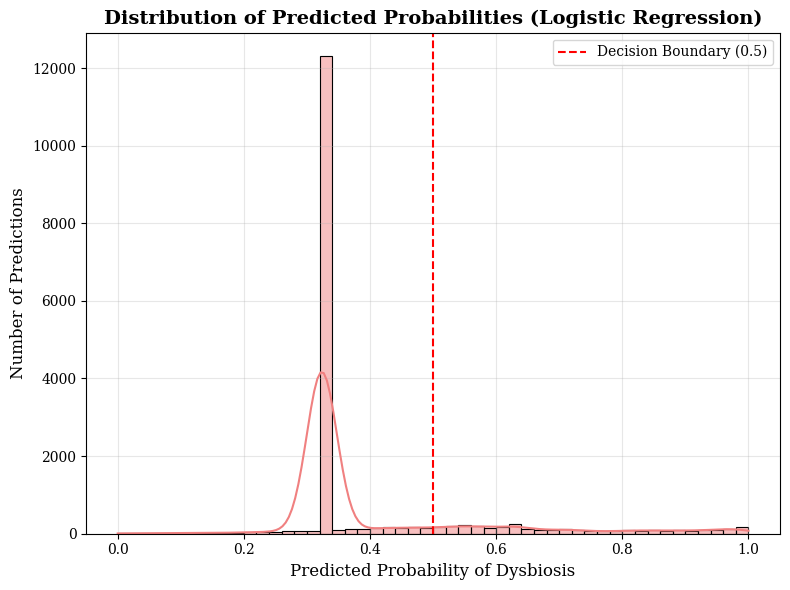

Saved LR prediction confidence distribution to 'Figure_LR_Confidence_Distribution.pdf'.
Percentage of LR predictions within low confidence range (0.5 ± 0.1): 9.88%

Training Random Forest (with class weights)...

Random Forest Results:
AUPRC: 0.2048 | AUROC: 0.5182 | F1: 0.1810 | Precision: 0.6071 | Recall: 0.1063

=== RF PREDICTION CONFIDENCE ANALYSIS ===


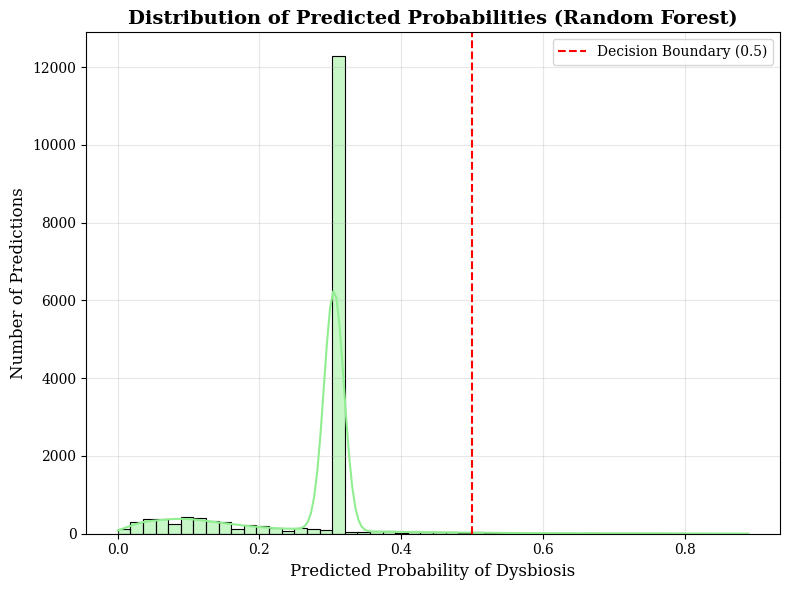

Saved RF prediction confidence distribution to 'Figure_RF_Confidence_Distribution.pdf'.
Percentage of RF predictions within low confidence range (0.5 ± 0.1): 1.97%


In [12]:
# @title 8. Traditional ML Baselines (Logistic Regression & Random Forest)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, f1_score, precision_score, recall_score, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Flattening 3D temporal windows for traditional ML models...")
# Flatten (Samples, 5, 118) -> (Samples, 590)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Ensure y_train and y_test are 1D
y_train_flat = y_train.ravel()
y_test_flat = y_test.ravel()

# --- 1. Logistic Regression ---
print("\nTraining Logistic Regression (with class weights)...")
# 'balanced' automatically adjusts for the 7.9% dysbiosis prevalence
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train_flat, y_train_flat)

# Predict probabilities for AUPRC, AUROC, and binary predictions for F1/Precision/Recall
lr_probs = lr_model.predict_proba(X_test_flat)[:, 1]
lr_preds = lr_model.predict(X_test_flat)

lr_auprc = average_precision_score(y_test_flat, lr_probs)
lr_auroc = roc_auc_score(y_test_flat, lr_probs)
lr_f1 = f1_score(y_test_flat, lr_preds)
lr_prec = precision_score(y_test_flat, lr_preds)
lr_rec = recall_score(y_test_flat, lr_preds)

print(f"Logistic Regression Results:")
print(f"AUPRC: {lr_auprc:.4f} | AUROC: {lr_auroc:.4f} | F1: {lr_f1:.4f} | Precision: {lr_prec:.4f} | Recall: {lr_rec:.4f}")

# --- LR Confidence/Variance Reporting ---
print("\n=== LR PREDICTION CONFIDENCE ANALYSIS ===")

# Plot distribution of prediction probabilities
plt.figure(figsize=(8, 6))
sns.histplot(lr_probs, bins=50, kde=True, color='lightcoral')
plt.title('Distribution of Predicted Probabilities (Logistic Regression)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Probability of Dysbiosis', fontsize=12)
plt.ylabel('Number of Predictions', fontsize=12)
plt.axvline(0.5, color='red', linestyle='--', label='Decision Boundary (0.5)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Figure_LR_Confidence_Distribution.pdf', format='pdf', dpi=600)
plt.show()
print("Saved LR prediction confidence distribution to 'Figure_LR_Confidence_Distribution.pdf'.")

# Quantify 'low confidence' predictions (probabilities close to 0.5)
low_confidence_threshold = 0.1 # e.g., predictions between 0.4 and 0.6
low_confidence_preds_count_lr = np.sum(
    (lr_probs >= (0.5 - low_confidence_threshold)) &
    (lr_probs <= (0.5 + low_confidence_threshold))
)
total_preds_lr = len(lr_probs)
low_confidence_percentage_lr = (low_confidence_preds_count_lr / total_preds_lr) * 100
print(f"Percentage of LR predictions within low confidence range (0.5 ± {low_confidence_threshold}): {low_confidence_percentage_lr:.2f}%")


# --- 2. Random Forest ---
print("\nTraining Random Forest (with class weights)...")
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train_flat, y_train_flat)

rf_probs = rf_model.predict_proba(X_test_flat)[:, 1]
rf_preds = rf_model.predict(X_test_flat)

rf_auprc = average_precision_score(y_test_flat, rf_probs)
rf_auroc = roc_auc_score(y_test_flat, rf_probs)
rf_f1 = f1_score(y_test_flat, rf_preds)
rf_prec = precision_score(y_test_flat, rf_preds)
rf_rec = recall_score(y_test_flat, rf_preds)

print(f"\nRandom Forest Results:")
print(f"AUPRC: {rf_auprc:.4f} | AUROC: {rf_auroc:.4f} | F1: {rf_f1:.4f} | Precision: {rf_prec:.4f} | Recall: {rf_rec:.4f}")

# --- RF Confidence/Variance Reporting ---
print("\n=== RF PREDICTION CONFIDENCE ANALYSIS ===")

# Plot distribution of prediction probabilities
plt.figure(figsize=(8, 6))
sns.histplot(rf_probs, bins=50, kde=True, color='lightgreen')
plt.title('Distribution of Predicted Probabilities (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Probability of Dysbiosis', fontsize=12)
plt.ylabel('Number of Predictions', fontsize=12)
plt.axvline(0.5, color='red', linestyle='--', label='Decision Boundary (0.5)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Figure_RF_Confidence_Distribution.pdf', format='pdf', dpi=600)
plt.show()
print("Saved RF prediction confidence distribution to 'Figure_RF_Confidence_Distribution.pdf'.")

# Quantify 'low confidence' predictions (probabilities close to 0.5)
low_confidence_preds_count_rf = np.sum(
    (rf_probs >= (0.5 - low_confidence_threshold)) &
    (rf_probs <= (0.5 + low_confidence_threshold))
)
total_preds_rf = len(rf_probs)
low_confidence_percentage_rf = (low_confidence_preds_count_rf / total_preds_rf) * 100
print(f"Percentage of RF predictions within low confidence range (0.5 ± {low_confidence_threshold}): {low_confidence_percentage_rf:.2f}%")


Training XGBoost...
XGBoost Results:
AUPRC: 0.3226 | AUROC: 0.7543 | F1: 0.3458 | Precision: 0.2450 | Recall: 0.5872

=== XGBOOST PREDICTION CONFIDENCE ANALYSIS ===


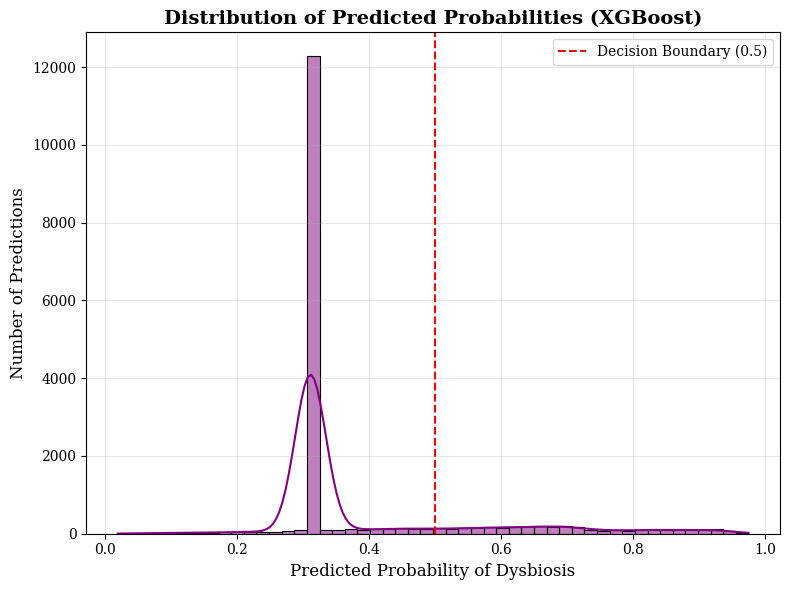

Saved XGBoost prediction confidence distribution to 'Figure_XGB_Confidence_Distribution.pdf'.
Percentage of XGBoost predictions within low confidence range (0.5 ± 0.1): 8.34%


In [13]:
# @title 09. Traditional ML Baseline: XGBoost
from xgboost import XGBClassifier
from sklearn.metrics import average_precision_score, f1_score, precision_score, recall_score, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("\nTraining XGBoost...")
# XGBoost uses 'scale_pos_weight' instead of 'class_weight' for imbalance
neg_cases = np.sum(y_train_flat == 0)
pos_cases = np.sum(y_train_flat == 1)
scale_weight = neg_cases / pos_cases

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_weight,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_flat, y_train_flat)

xgb_probs = xgb_model.predict_proba(X_test_flat)[:, 1]
xgb_preds = xgb_model.predict(X_test_flat)

xgb_auprc = average_precision_score(y_test_flat, xgb_probs)
xgb_auroc = roc_auc_score(y_test_flat, xgb_probs)
xgb_f1 = f1_score(y_test_flat, xgb_preds)
xgb_prec = precision_score(y_test_flat, xgb_preds)
xgb_rec = recall_score(y_test_flat, xgb_preds)

print(f"XGBoost Results:")
print(f"AUPRC: {xgb_auprc:.4f} | AUROC: {xgb_auroc:.4f} | F1: {xgb_f1:.4f} | Precision: {xgb_prec:.4f} | Recall: {xgb_rec:.4f}")

# --- XGBoost Confidence/Variance Reporting ---
print("\n=== XGBOOST PREDICTION CONFIDENCE ANALYSIS ===")

# Plot distribution of prediction probabilities
plt.figure(figsize=(8, 6))
sns.histplot(xgb_probs, bins=50, kde=True, color='purple')
plt.title('Distribution of Predicted Probabilities (XGBoost)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Probability of Dysbiosis', fontsize=12)
plt.ylabel('Number of Predictions', fontsize=12)
plt.axvline(0.5, color='red', linestyle='--', label='Decision Boundary (0.5)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Figure_XGB_Confidence_Distribution.pdf', format='pdf', dpi=600)
plt.show()
print("Saved XGBoost prediction confidence distribution to 'Figure_XGB_Confidence_Distribution.pdf'.")

# Quantify 'low confidence' predictions (probabilities close to 0.5)
low_confidence_threshold = 0.1 # e.g., predictions between 0.4 and 0.6
low_confidence_preds_count_xgb = np.sum(
    (xgb_probs >= (0.5 - low_confidence_threshold)) &
    (xgb_probs <= (0.5 + low_confidence_threshold))
)
total_preds_xgb = len(xgb_probs)
low_confidence_percentage_xgb = (low_confidence_preds_count_xgb / total_preds_xgb) * 100
print(f"Percentage of XGBoost predictions within low confidence range (0.5 ± {low_confidence_threshold}): {low_confidence_percentage_xgb:.2f}%")

Computed Class Weights: {0: np.float64(0.5431924710707485), 1: np.float64(6.288045782111064)}

Training Baseline Bi-LSTM...
Epoch 1/50
464/464 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - auprc: 0.3059 - auroc: 0.7462 - loss: 0.5827 - precision: 0.1808 - recall: 0.6450 - val_auprc: 0.3108 - val_auroc: 0.7571 - val_loss: 0.5103 - val_precision: 0.2465 - val_recall: 0.6417
Epoch 2/50
464/464 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - auprc: 0.3278 - auroc: 0.7586 - loss: 0.5624 - precision: 0.2380 - recall: 0.6223 - val_auprc: 0.3100 - val_auroc: 0.7582 - val_loss: 0.5105 - val_precision: 0.2457 - val_recall: 0.6476
Epoch 3/50
464/464 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - auprc: 0.3322 - auroc: 0.7593 - loss: 0.5599 - precision: 0.2389 - recall: 0.6255 - val_auprc: 0.3032 - val_auroc: 0.7554 - val_loss: 0.5047 - val_precision: 0.2442 - val_recall: 0.6373
Epoch 4/50
464/464 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - auprc: 0.3411 - auroc: 0.7595 - loss: 0.5580 - precision: 0.2420 - recall: 0.6291 - val_auprc: 0.29

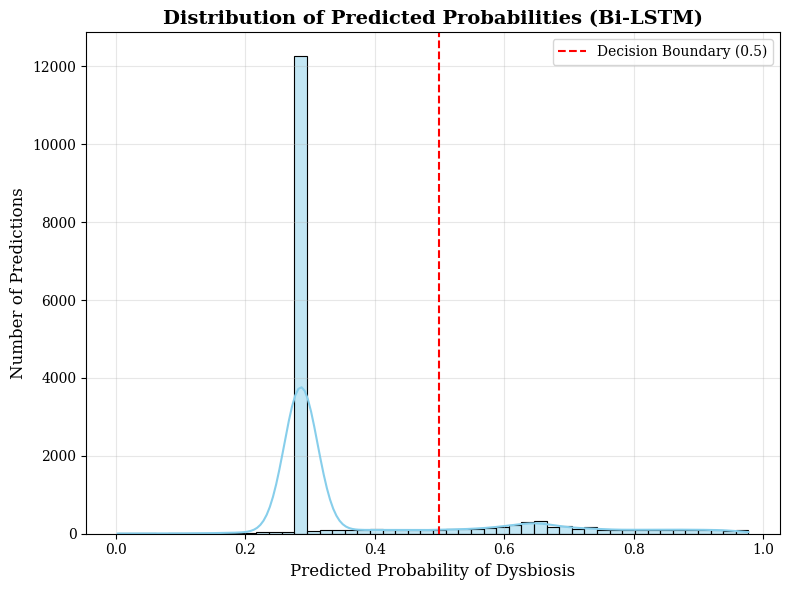

Saved prediction confidence distribution to 'Figure_Confidence_Distribution.pdf'.
Percentage of predictions within low confidence range (0.5 ± 0.1): 6.90%


In [14]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.metrics import AUC, Precision, Recall
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate Dynamic Class Weights
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {0: weights[0], 1: weights[1]}
print(f"Computed Class Weights: {class_weight_dict}")

# 2. Define the Baseline Architecture
def build_baseline_bilstm(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        Bidirectional(LSTM(64, return_sequences=False)),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])

    # 3. Compile with AUPRC as the primary metric
    metrics = [
        AUC(curve='PR', name='auprc'),
        AUC(curve='ROC', name='auroc'),
        Precision(name='precision'),
        Recall(name='recall')
    ]

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=metrics)
    return model

input_dim = (X_train.shape[1], X_train.shape[2])
baseline_model = build_baseline_bilstm(input_dim)

# 4. Train the Model
early_stop = EarlyStopping(
    monitor='val_auprc',
    mode='max',
    patience=10,
    restore_best_weights=True
)

print("\nTraining Baseline Bi-LSTM...")
history = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=128,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

# 5. Evaluate on the Unseen Test Set
print("\n=== FINAL TEST SET PERFORMANCE ===")
test_results = baseline_model.evaluate(X_test, y_test, verbose=0)

# Robust metric extraction
metric_map = {name: val for name, val in zip(baseline_model.metrics_names, test_results)}

# Use .get() to handle potential name variations in different TF versions
auprc_bilstm = metric_map.get('auprc', test_results[1])
auroc_bilstm = metric_map.get('auroc', test_results[2]) # Added AUROC extraction
precision_bilstm = metric_map.get('precision', test_results[3])
recall_bilstm = metric_map.get('recall', test_results[4])

# Get model predictions for F1 score calculation
y_pred_probs = baseline_model.predict(X_test).ravel()
y_pred_binary = (y_pred_probs > 0.5).astype(int)

f1_bilstm = f1_score(y_test, y_pred_binary)

# Print in the requested format
print(f"AUPRC: {auprc_bilstm:.4f} | AUROC: {auroc_bilstm:.4f} | F1: {f1_bilstm:.4f} | Precision: {precision_bilstm:.4f} | Recall: {recall_bilstm:.4f}")

# 6. Confidence/Variance Reporting
print("\n=== PREDICTION CONFIDENCE ANALYSIS ===")

# Plot distribution of prediction probabilities
plt.figure(figsize=(8, 6))
sns.histplot(y_pred_probs, bins=50, kde=True, color='skyblue')
plt.title('Distribution of Predicted Probabilities (Bi-LSTM)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Probability of Dysbiosis', fontsize=12)
plt.ylabel('Number of Predictions', fontsize=12)
plt.axvline(0.5, color='red', linestyle='--', label='Decision Boundary (0.5)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Figure_Confidence_Distribution.pdf', format='pdf', dpi=600)
plt.show()
print("Saved prediction confidence distribution to 'Figure_Confidence_Distribution.pdf'.")

# Quantify 'low confidence' predictions (probabilities close to 0.5)
low_confidence_threshold = 0.1 # e.g., predictions between 0.4 and 0.6
low_confidence_preds_count = np.sum(
    (y_pred_probs >= (0.5 - low_confidence_threshold)) &
    (y_pred_probs <= (0.5 + low_confidence_threshold))
)

total_preds = len(y_pred_probs)
low_confidence_percentage = (low_confidence_preds_count / total_preds) * 100

print(f"Percentage of predictions within low confidence range (0.5 ± {low_confidence_threshold}): {low_confidence_percentage:.2f}%")

Combined distribution figure saved as 'Figure_Combined_Confidence_Distribution.pdf'.


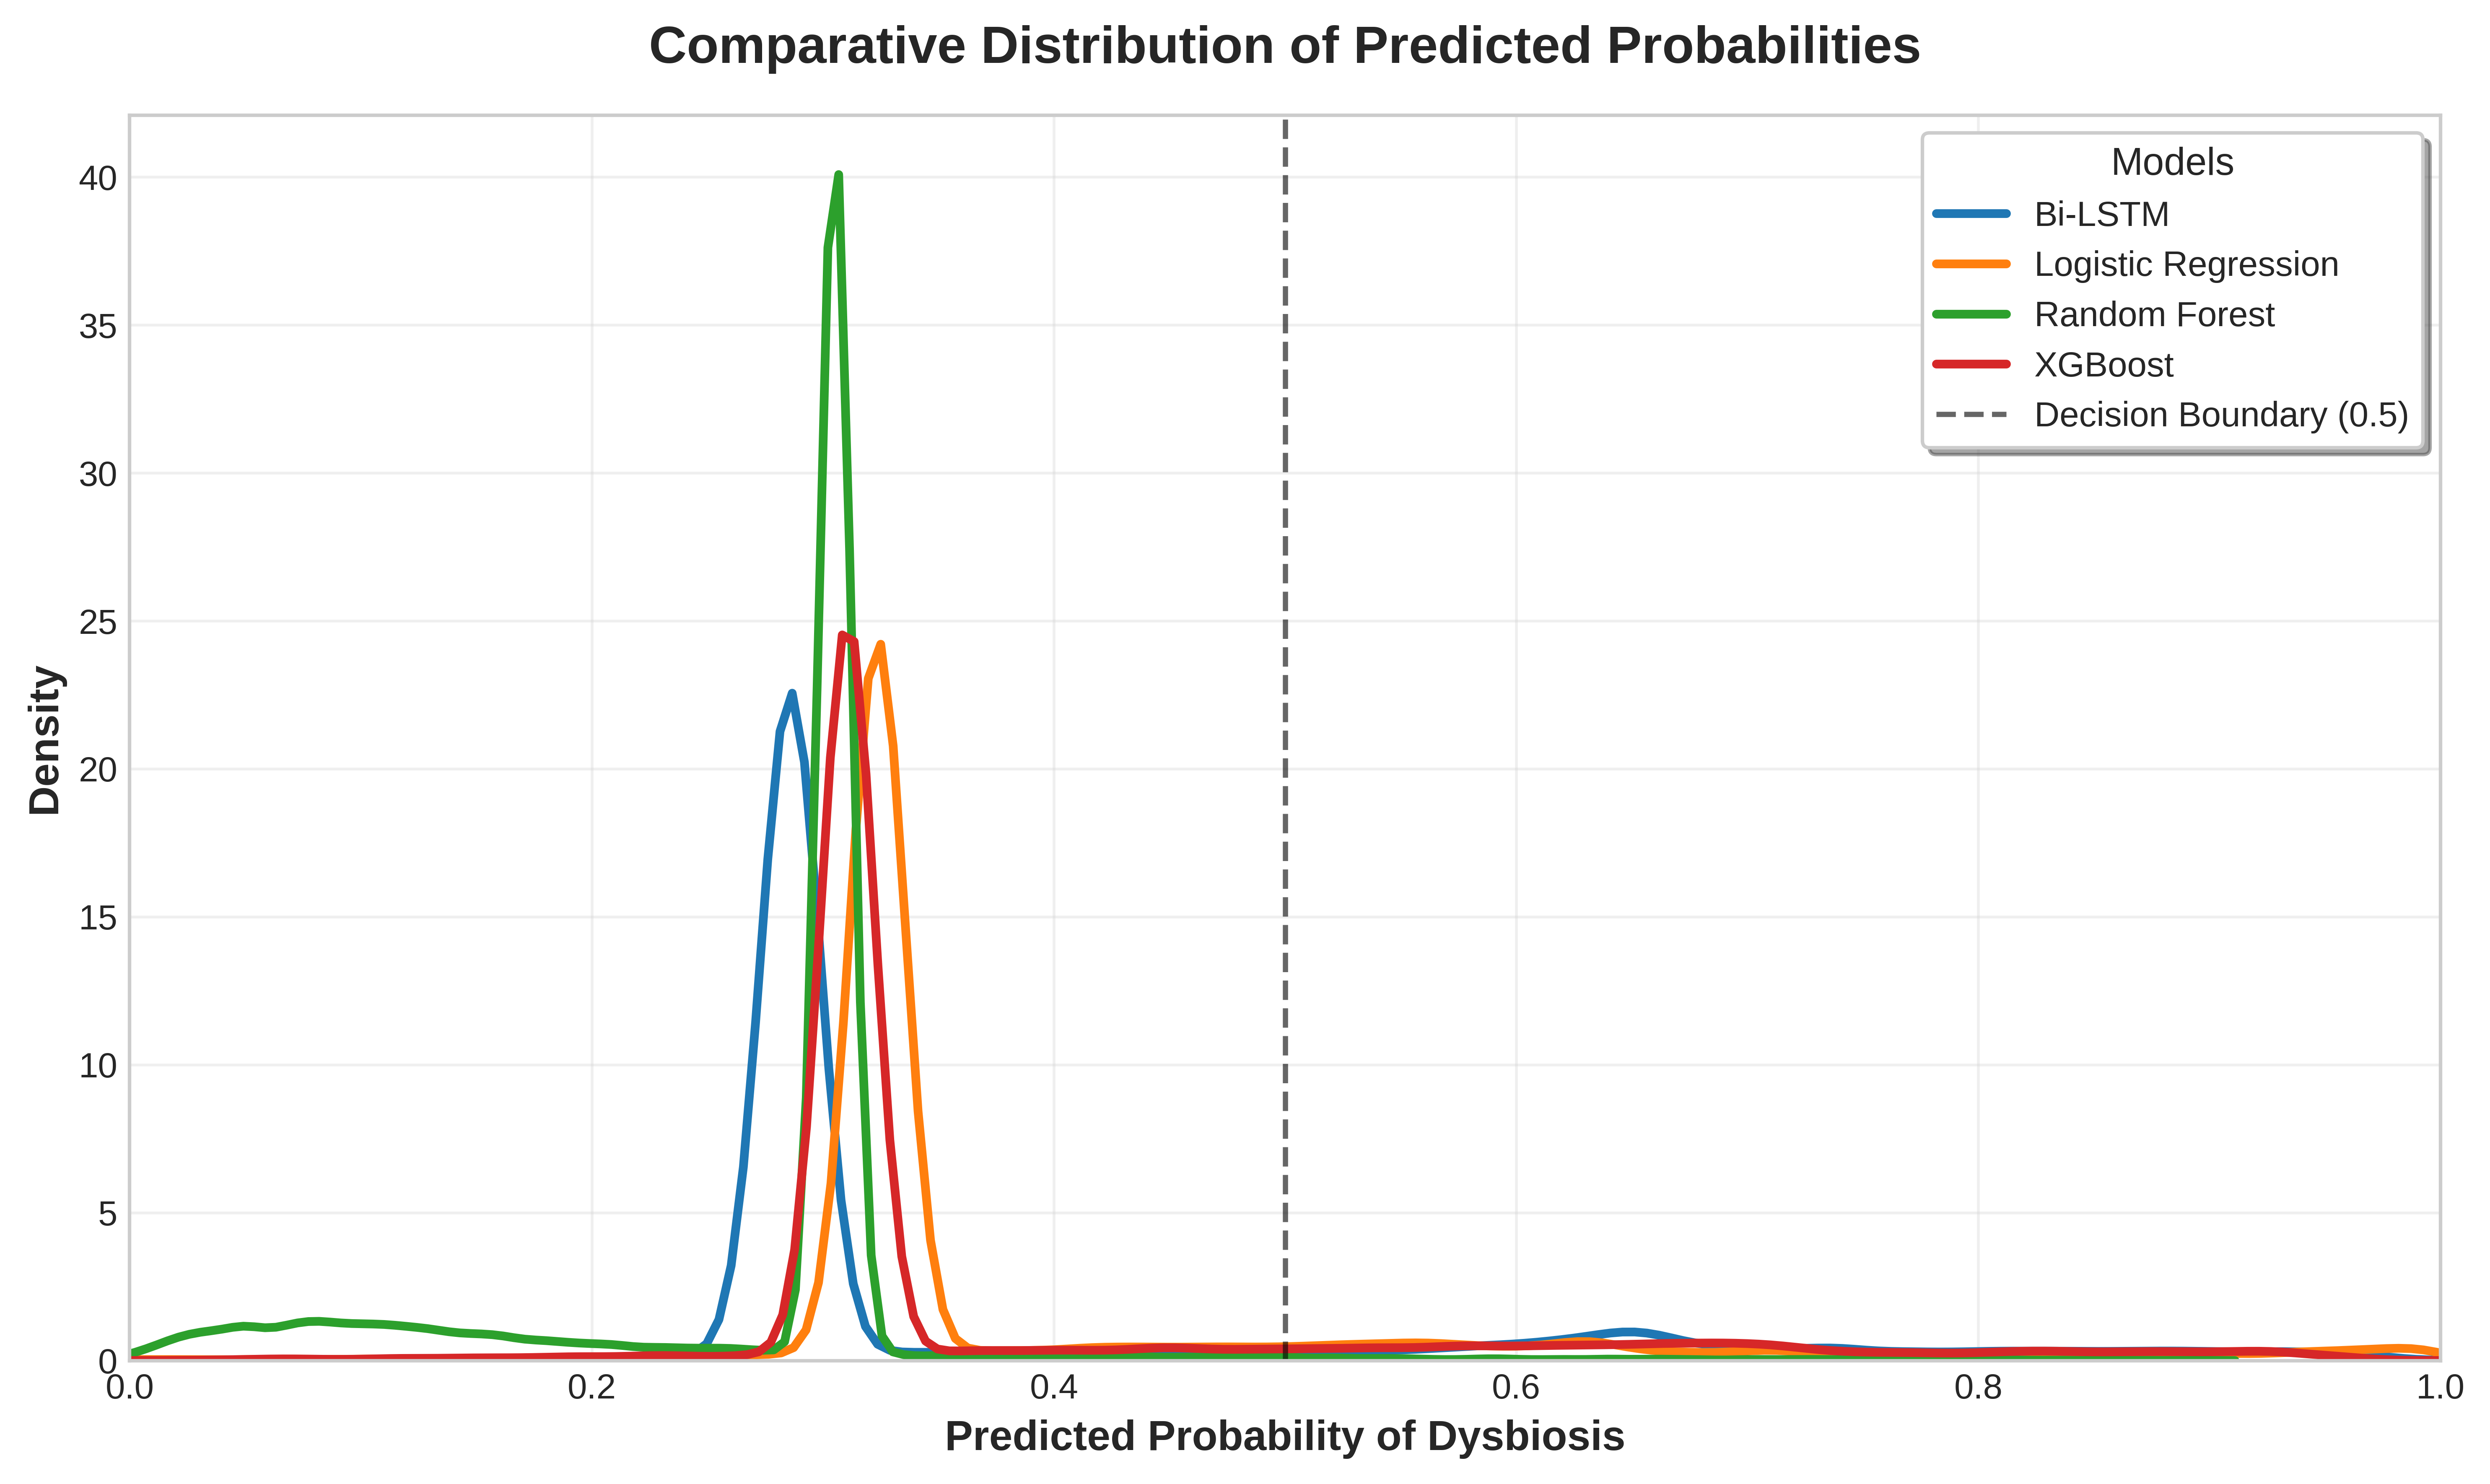

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Consolidate predictions into a single DataFrame for plotting
dist_df = pd.DataFrame({
    'Bi-LSTM': y_pred_probs,
    'Logistic Regression': lr_probs,
    'Random Forest': rf_probs,
    'XGBoost': xgb_probs
})

# 2. Create the combined figure
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(10, 6), dpi=600)

# Define standard colors to match previous PR/ROC curves
colors = {'Bi-LSTM': '#1f77b4', 'Logistic Regression': '#ff7f0e', 'Random Forest': '#2ca02c', 'XGBoost': '#d62728'}

for model in dist_df.columns:
    sns.kdeplot(dist_df[model], bw_adjust=0.5, label=model, color=colors[model], linewidth=2.5)

# 3. Formatting
plt.axvline(0.5, color='black', linestyle='--', alpha=0.6, label='Decision Boundary (0.5)')
plt.title('Comparative Distribution of Predicted Probabilities', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Predicted Probability of Dysbiosis', fontsize=12, fontweight='bold')
plt.ylabel('Density', fontsize=12, fontweight='bold')
plt.xlim(0, 1)
plt.legend(title='Models', title_fontsize='11', fontsize='10', frameon=True, shadow=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# 4. Save and Show
plt.savefig('Figure_Combined_Confidence_Distribution.pdf', format='pdf', bbox_inches='tight', dpi=600)
print("Combined distribution figure saved as 'Figure_Combined_Confidence_Distribution.pdf'.")
plt.show()

530/530 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Figure saved as 'Figure_1_PR_Curve.pdf'. Upload this to your Overleaf project.


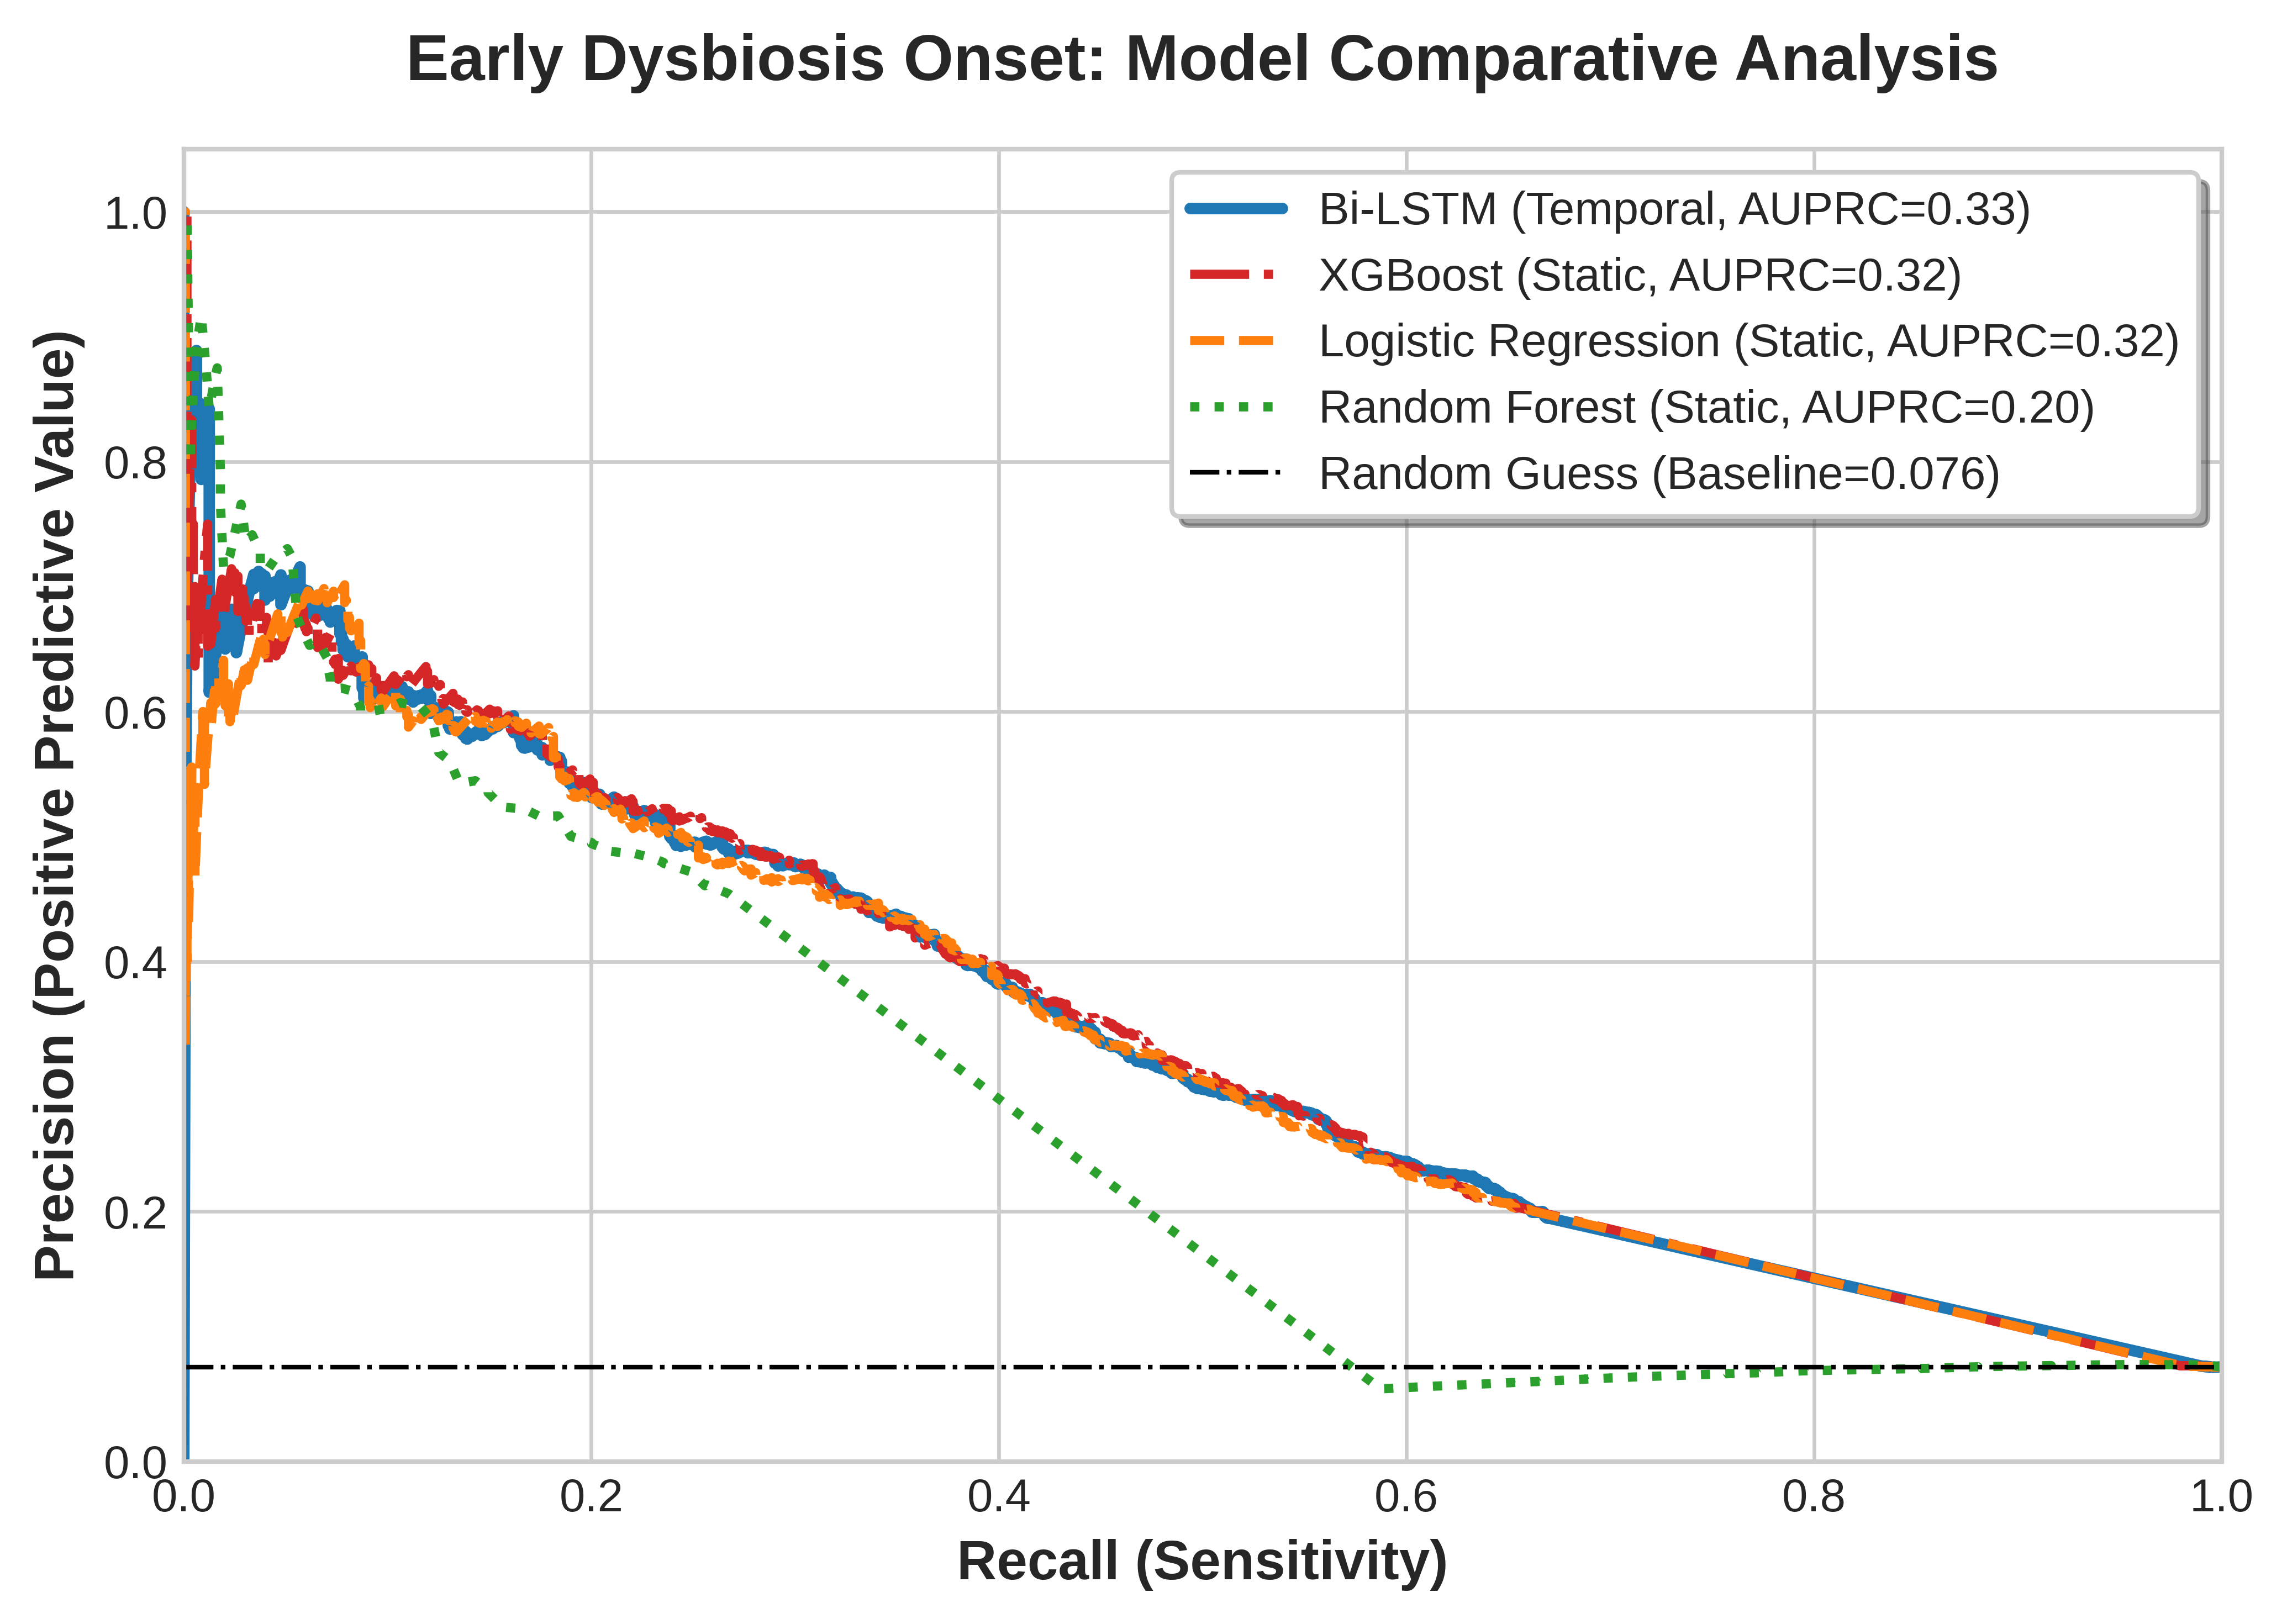

In [16]:
# @title 10. Generate Publication-Ready PR Curve
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# Get probabilities for the 5-day Bi-LSTM
bilstm_probs = baseline_model.predict(X_test).ravel()

# Calculate Precision-Recall coordinates for all models
prec_lstm, rec_lstm, _ = precision_recall_curve(y_test, bilstm_probs)
prec_lr, rec_lr, _ = precision_recall_curve(y_test_flat, lr_probs)
prec_rf, rec_rf, _ = precision_recall_curve(y_test_flat, rf_probs)
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test_flat, xgb_probs)

# Calculate AUPRC for labels (using existing variables)
# AUPRC values are already computed and available from previous cells: auprc_bilstm, lr_auprc, rf_auprc, xgb_auprc

# Plot formatting (IEEE Style)
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(7, 5), dpi=600)

# Plot the lines
plt.plot(rec_lstm, prec_lstm, color='#1f77b4', linewidth=2.5, label=f'Bi-LSTM (Temporal, AUPRC={auprc_bilstm:.2f})')
plt.plot(rec_xgb, prec_xgb, color='#d62728', linewidth=2, linestyle='-.', label=f'XGBoost (Static, AUPRC={xgb_auprc:.2f})')
plt.plot(rec_lr, prec_lr, color='#ff7f0e', linewidth=2, linestyle='--', label=f'Logistic Regression (Static, AUPRC={lr_auprc:.2f})')
plt.plot(rec_rf, prec_rf, color='#2ca02c', linewidth=2, linestyle=':', label=f'Random Forest (Static, AUPRC={rf_auprc:.2f})')

# The "Random Guess" baseline
baseline_rate = y_test.sum() / len(y_test)
plt.axhline(y=baseline_rate, color='black', linestyle='-.', linewidth=1, label=f'Random Guess (Baseline={baseline_rate:.3f})')

# Labels and Title
plt.xlabel('Recall (Sensitivity)', fontsize=12, fontweight='bold')
plt.ylabel('Precision (Positive Predictive Value)', fontsize=12, fontweight='bold')
plt.title('Early Dysbiosis Onset: Model Comparative Analysis', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc='upper right', fontsize=10, frameon=True, shadow=True)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()

# Save as high-res PDF for Overleaf
plt.savefig('Figure_1_PR_Curve.pdf', format='pdf', bbox_inches='tight', dpi=600)
print("Figure saved as 'Figure_1_PR_Curve.pdf'. Upload this to your Overleaf project.")
plt.show()

530/530 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Figure saved as 'Figure_AUROC_Curve.pdf'.


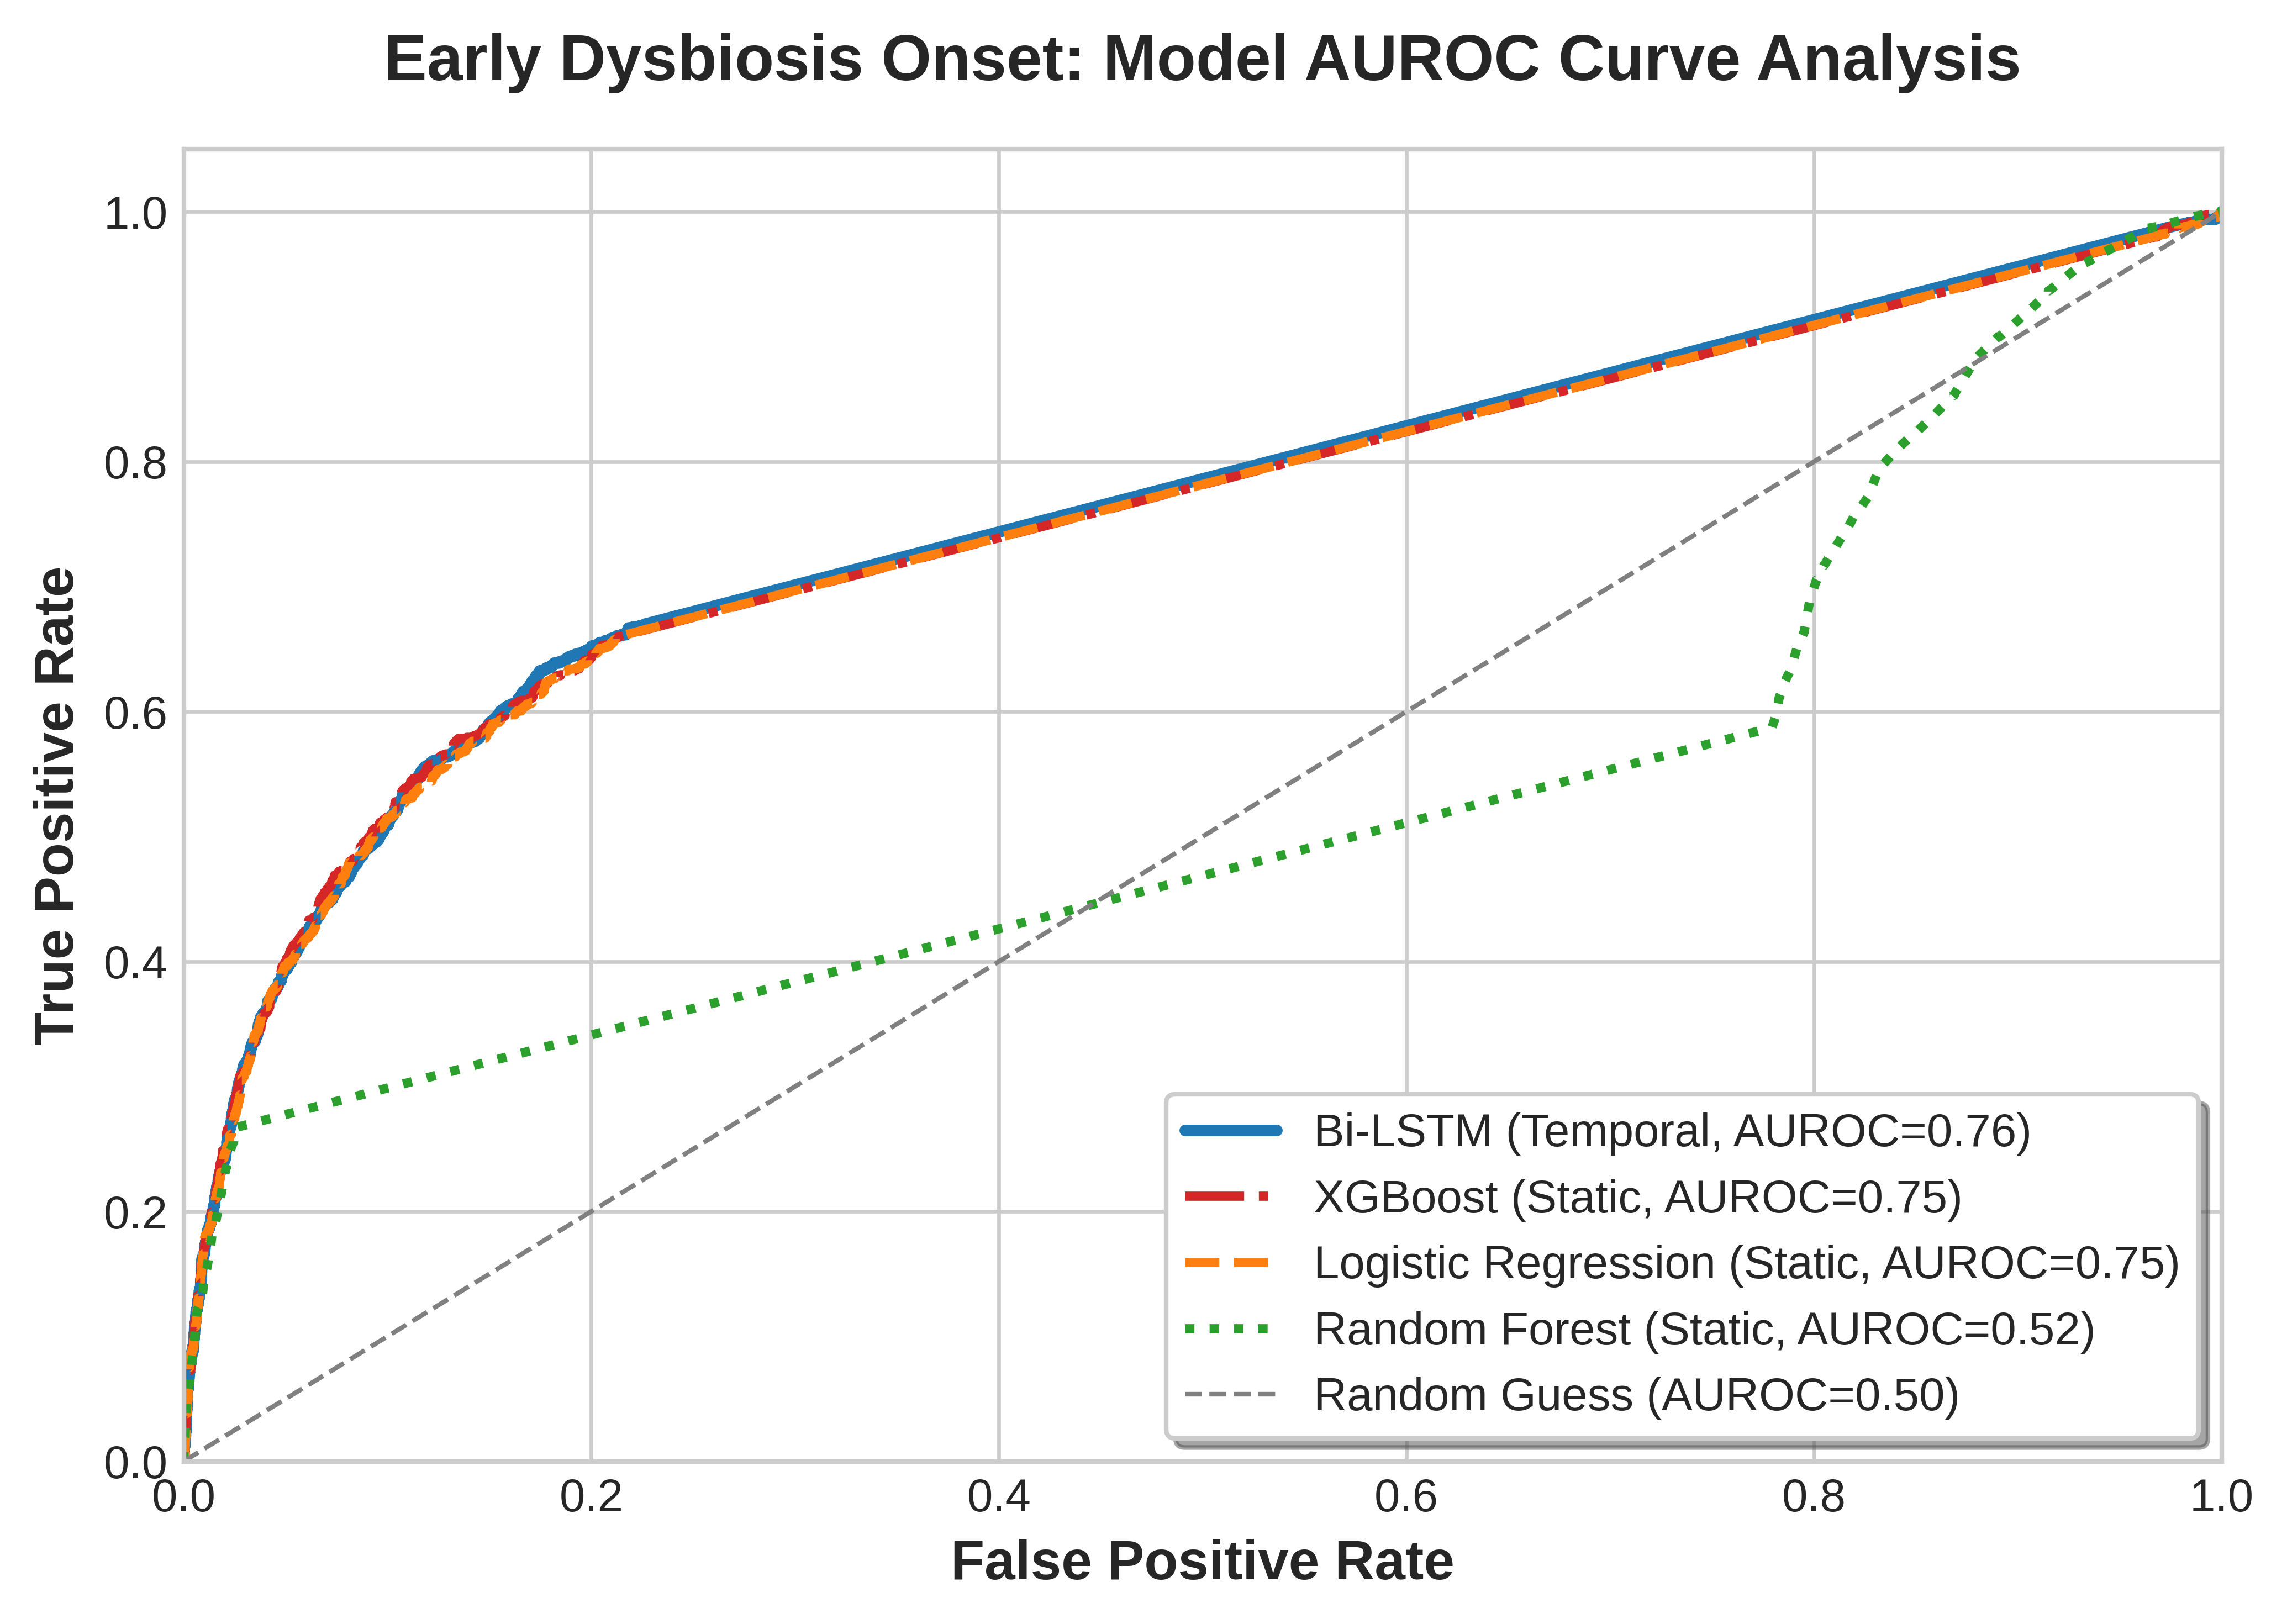

In [17]:
# @title 11. Generate Publication-Ready AUC(ROC) Curve
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Get probabilities for the 5-day Bi-LSTM
bilstm_probs = baseline_model.predict(X_test).ravel()

# Calculate ROC curve coordinates for all models
fpr_lstm, tpr_lstm, _ = roc_curve(y_test, bilstm_probs)
fpr_lr, tpr_lr, _ = roc_curve(y_test_flat, lr_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test_flat, rf_probs)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test_flat, xgb_probs)

# Calculate AUROC values (already available from previous cells: auroc_bilstm, lr_auroc, rf_auroc, xgb_auroc)

# Plot formatting (IEEE Style)
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(7, 5), dpi=600)

# Plot the lines
plt.plot(fpr_lstm, tpr_lstm, color='#1f77b4', linewidth=2.5, label=f'Bi-LSTM (Temporal, AUROC={auroc_bilstm:.2f})')
plt.plot(fpr_xgb, tpr_xgb, color='#d62728', linewidth=2, linestyle='-.', label=f'XGBoost (Static, AUROC={xgb_auroc:.2f})')
plt.plot(fpr_lr, tpr_lr, color='#ff7f0e', linewidth=2, linestyle='--', label=f'Logistic Regression (Static, AUROC={lr_auroc:.2f})')
plt.plot(fpr_rf, tpr_rf, color='#2ca02c', linewidth=2, linestyle=':', label=f'Random Forest (Static, AUROC={rf_auroc:.2f})')

# Plot the random guess line
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random Guess (AUROC=0.50)')

# Labels and Title
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('Early Dysbiosis Onset: Model AUROC Curve Analysis', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc='lower right', fontsize=10, frameon=True, shadow=True)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()

# Save as high-res PDF
plt.savefig('Figure_AUROC_Curve.pdf', format='pdf', bbox_inches='tight', dpi=600)
print("Figure saved as 'Figure_AUROC_Curve.pdf'.")
plt.show()

In [25]:
# @title 12. Ablation Study
print("--- Running 3-Day Window Ablation Study ---")

# 1. Regenerate sequences with 3 days instead of 5
OBS_LEN_ABLATION = 3
TARGET_LEN = 2

X_train_3d, y_train_3d = build_benchmark_sequences(df_train, active_features, scaler, fit_scaler=False, obs_len=OBS_LEN_ABLATION, target_len=TARGET_LEN)
X_val_3d, y_val_3d = build_benchmark_sequences(df_val, active_features, scaler, fit_scaler=False, obs_len=OBS_LEN_ABLATION, target_len=TARGET_LEN)
X_test_3d, y_test_3d = build_benchmark_sequences(df_test, active_features, scaler, fit_scaler=False, obs_len=OBS_LEN_ABLATION, target_len=TARGET_LEN)

# 2. Re-calculate Class Weights
weights_3d = compute_class_weight('balanced', classes=np.unique(y_train_3d), y=y_train_3d)
class_weight_dict_3d = {0: weights_3d[0], 1: weights_3d[1]}

# 3. Build and Train the exact same Bi-LSTM architecture
input_dim_3d = (X_train_3d.shape[1], X_train_3d.shape[2])
ablation_model = build_baseline_bilstm(input_dim_3d)

ablation_early_stop = EarlyStopping(monitor='val_auprc', mode='max', patience=10, restore_best_weights=True)

print("Training 3-Day Ablation Bi-LSTM...")
ablation_history = ablation_model.fit(
    X_train_3d, y_train_3d,
    validation_data=(X_val_3d, y_val_3d),
    epochs=50,
    batch_size=128,
    class_weight=class_weight_dict_3d,
    callbacks=[ablation_early_stop],
    verbose=0 # Set to 0 to save your screen space
)

# 4. Evaluate
test_results_3d = ablation_model.evaluate(X_test_3d, y_test_3d, verbose=0)
ablation_auprc = test_results_3d[1] # Assuming AUPRC is the second metric in your compile list
print(f"\n=== ABLATION RESULTS ===")
print(f"5-Day Window AUPRC (Original): {auprc_bilstm:.4f}")
print(f"3-Day Window AUPRC (Ablation): {ablation_auprc:.4f}")

--- Running 3-Day Window Ablation Study ---
Training 3-Day Ablation Bi-LSTM...

=== ABLATION RESULTS ===
5-Day Window AUPRC (Original): 0.3319
3-Day Window AUPRC (Ablation): 0.3040


In [19]:
# @title 13. Extract Feature Importance from Logistic Regression
import pandas as pd
import numpy as np

# Get the coefficients from the trained Logistic Regression model
# Since it's binary, there is 1 set of coefficients. Shape is (1, n_features)
coefficients = lr_model.coef_[0]

# The Logistic Regression model was trained on the flattened sequence of active_features
# We need to create expanded feature names to match the flattened input (5 time steps * len(active_features)).
expanded_feature_names = []
for i in range(OBS_LEN): # OBS_LEN is 5, representing the 5-day observation window
    for feature in active_features: # Use active_features instead of feature_cols
        # Label features with their corresponding time step, e.g., '_t-4' for the oldest day, '_t0' for the most recent.
        expanded_feature_names.append(f'{feature}_t-{OBS_LEN - 1 - i}')

feature_names = expanded_feature_names

# Create a DataFrame to view the top features
importance_df = pd.DataFrame({
    'Feature (Taxa)': feature_names,
    'Coefficient': coefficients,
    'Absolute_Importance': np.abs(coefficients)
})

# Sort by absolute importance (the most predictive features, either for or against dysbiosis)
top_10_features = importance_df.sort_values(by='Absolute_Importance', ascending=False).head(10)

print("=== TOP 10 MOST PREDICTIVE FEATURES (LOGISTIC REGRESSION) ===")
print(top_10_features[['Feature (Taxa)', 'Coefficient']].to_string(index=False))


=== TOP 10 MOST PREDICTIVE FEATURES (LOGISTIC REGRESSION) ===
                  Feature (Taxa)  Coefficient
              Ruminococcus 2_t-0    -3.112944
[Ruminococcus] torques group_t-0    -2.967470
         Ruminiclostridium 5_t-0    -2.560742
                 Leuconostoc_t-1     2.457892
                 Leuconostoc_t-2     2.372911
              Ruminococcus 2_t-1    -2.276090
           Corynebacterium 1_t-0     2.253931
             Intestinibacter_t-4    -2.242973
     Ruminococcaceae UCG-002_t-3     2.062622
            Stenotrophomonas_t-2     2.037770


In [20]:
# @title 14. Exploratory Data Analysis (EDA) Metrics
import numpy as np
import pandas as pd

print("=== HCT-Microbiome Benchmark EDA STATISTICS ===")

# 1. Calculate Sparsity on the raw 118 features
# X_train_raw was calculated earlier, or we can just use df_train
# raw_abundance_matrix = df_train[active_features].values
# total_elements = raw_abundance_matrix.size
# zero_elements = np.count_nonzero(raw_abundance_matrix == 0)
# sparsity_percentage = (zero_elements / total_elements) * 100

# Using the overall dataset sparsity calculated in 'agnBpNQsoXtx' for consistency
# If 'sparsity_percentage_all' is not defined, calculate a fallback
if 'sparsity_percentage_all' not in globals():
    raw_abundance_matrix_all = df[active_features].values
    total_elements_all = raw_abundance_matrix_all.size
    zero_elements_all = np.count_nonzero(raw_abundance_matrix_all == 0)
    sparsity_percentage_all = (zero_elements_all / total_elements_all) * 100

print(f"1. Matrix Sparsity: {sparsity_percentage_all:.2f}% of the data are exact zeros.")

# 2. Longitudinal Density (Days per patient)
days_per_patient = df_train.groupby('PatientID').size()
mean_days = days_per_patient.mean()
median_days = days_per_patient.median()
max_days = days_per_patient.max()

print(f"2. Longitudinal Density: Mean = {mean_days:.1f} days, Median = {median_days:.1f} days, Max = {max_days} days.")

# 3. Target Variable Distribution
print(f"3. Class Imbalance (Prevalence): 7.9% Dysbiosis (Calculated previously).")

=== HCT-Microbiome Benchmark EDA STATISTICS ===
1. Matrix Sparsity: 98.04% of the data are exact zeros.
2. Longitudinal Density: Mean = 51.3 days, Median = 51.0 days, Max = 102 days.
3. Class Imbalance (Prevalence): 7.9% Dysbiosis (Calculated previously).


Saved Figure_2_Combined_EDA.pdf


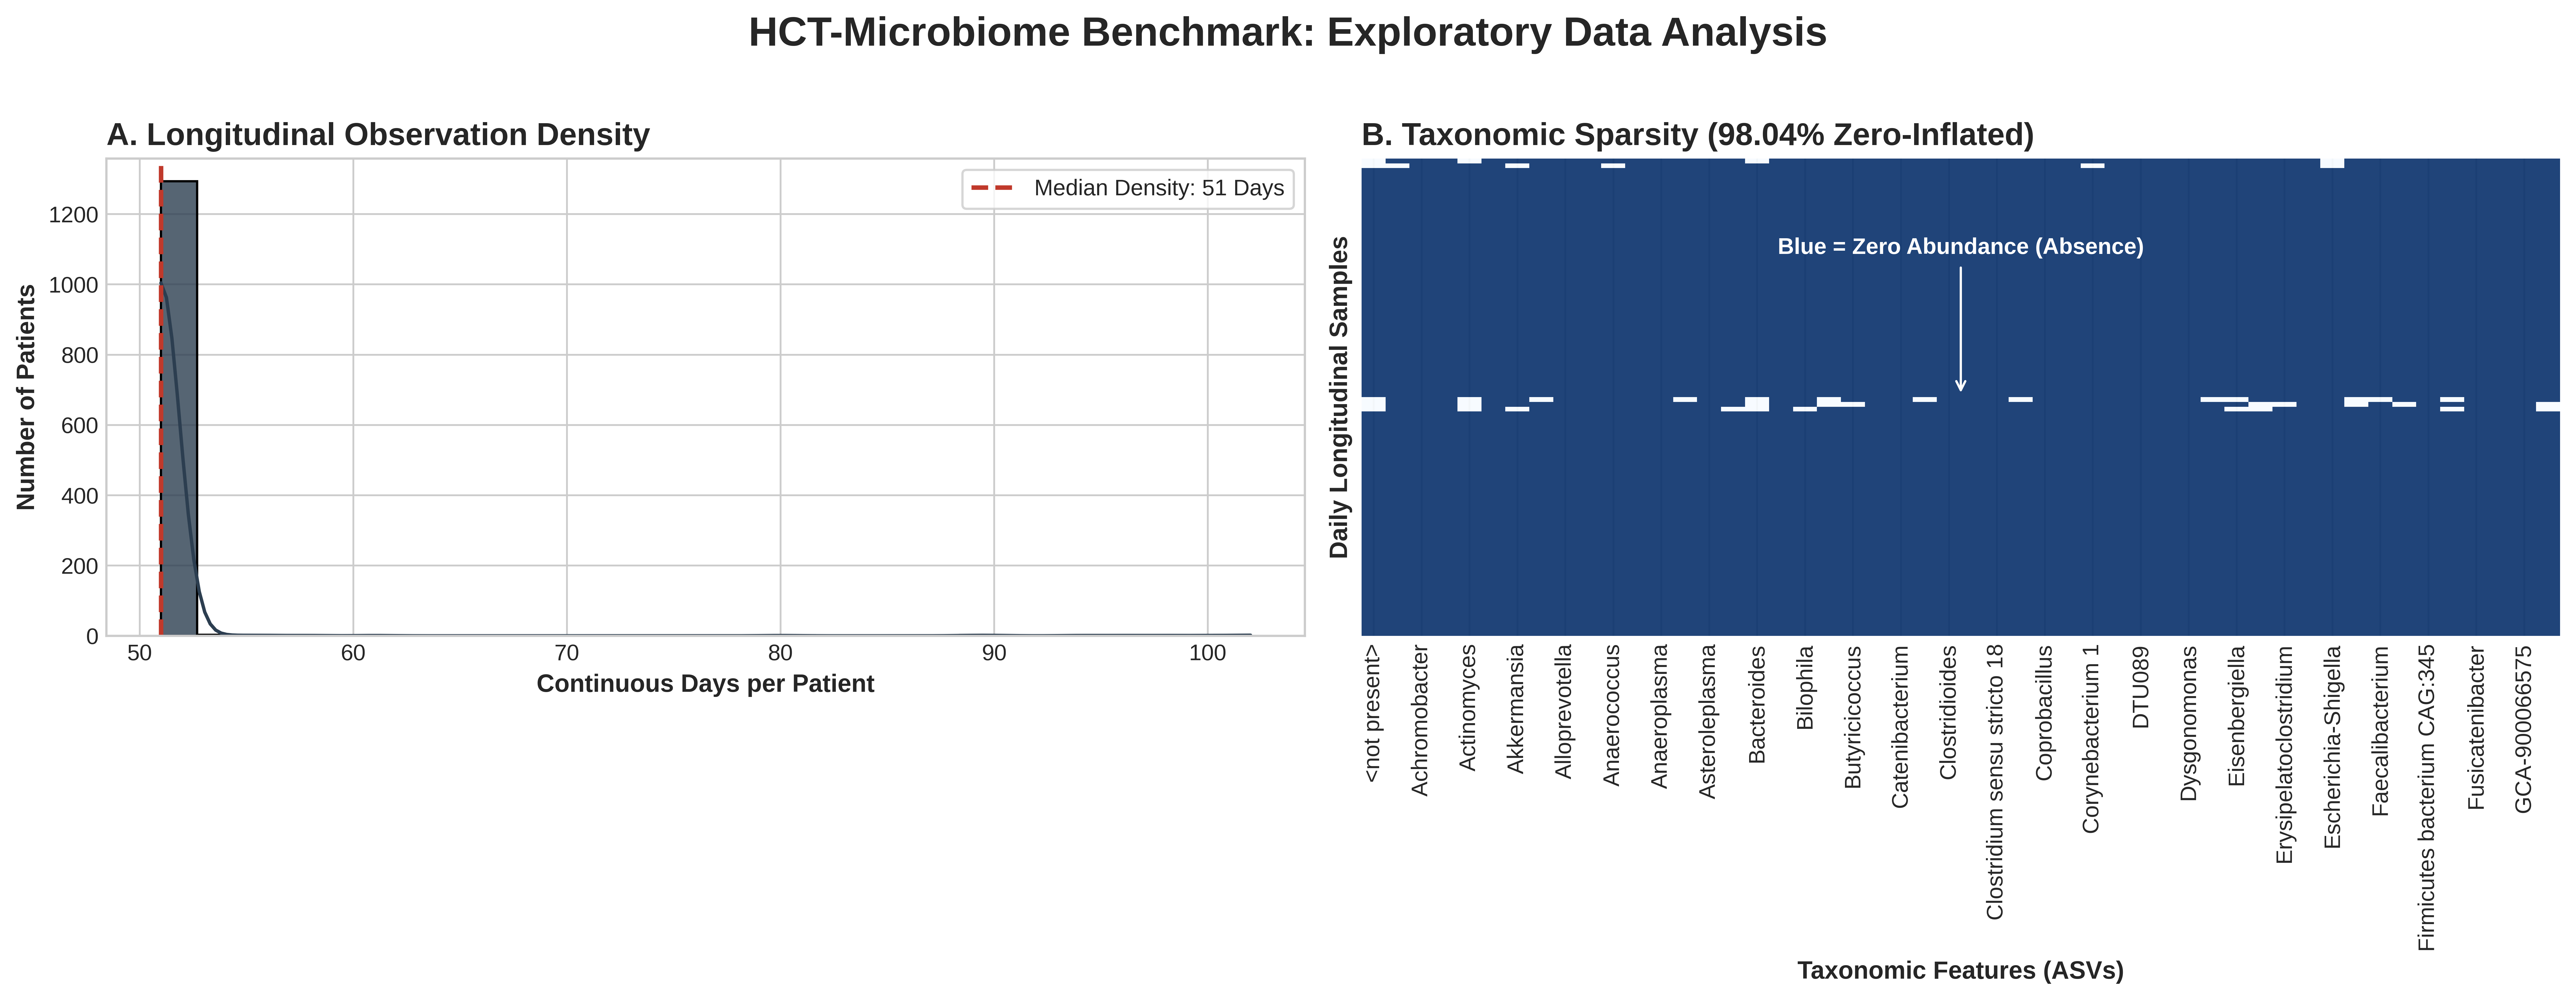

In [21]:
# @title 15. Generate Publication-Ready EDA Figures (Combined Panel)
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional context
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=600)
plt.subplots_adjust(wspace=0.3)

# --- Panel A: Longitudinal Trajectory Density ---
days_per_patient = df_train.groupby('PatientID').size()
sns.histplot(days_per_patient, bins=30, color='#2c3e50', kde=True, ax=ax1, alpha=0.8)
ax1.axvline(days_per_patient.median(), color='#c0392b', linestyle='--', lw=2,
            label=f'Median Density: {days_per_patient.median():.0f} Days')

ax1.set_title('A. Longitudinal Observation Density', fontsize=14, fontweight='bold', loc='left')
ax1.set_xlabel('Continuous Days per Patient', fontsize=11, fontweight='bold')
ax1.set_ylabel('Number of Patients', fontsize=11, fontweight='bold')
ax1.legend(frameon=True, facecolor='white')

# --- Panel B: Taxonomic Sparsity Heatmap (Subset) ---
# Subset to show the checkerboard of sparsity clearly
subset_df = df_train[active_features].iloc[100:200, :50]

# Use a clean binary colormap: White for abundance, Blue for zero
sns.heatmap(subset_df == 0, cbar=False, cmap='Blues', yticklabels=False, ax=ax2, alpha=0.9)

ax2.set_title(f'B. Taxonomic Sparsity ({sparsity_percentage_all:.2f}% Zero-Inflated)', fontsize=14, fontweight='bold', loc='left')
ax2.set_xlabel('Taxonomic Features (ASVs)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Daily Longitudinal Samples', fontsize=11, fontweight='bold')

# Add annotation for interpretability
ax2.annotate('Blue = Zero Abundance (Absence)', xy=(25, 50), xytext=(25, 20),
             ha='center', color='white', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='white'))

# Final Layout refinement
plt.suptitle('HCT-Microbiome Benchmark: Exploratory Data Analysis', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()

# Save as high-res PDF for manuscript
plt.savefig('Figure_2_Combined_EDA.pdf', format='pdf', bbox_inches='tight')
print("Saved Figure_2_Combined_EDA.pdf")
plt.show()

Generating All-Models Trajectory Plot for Patient: 1036
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Saved comparison plot to 'Figure_Patient_1036_Model_Comparison.pdf'.


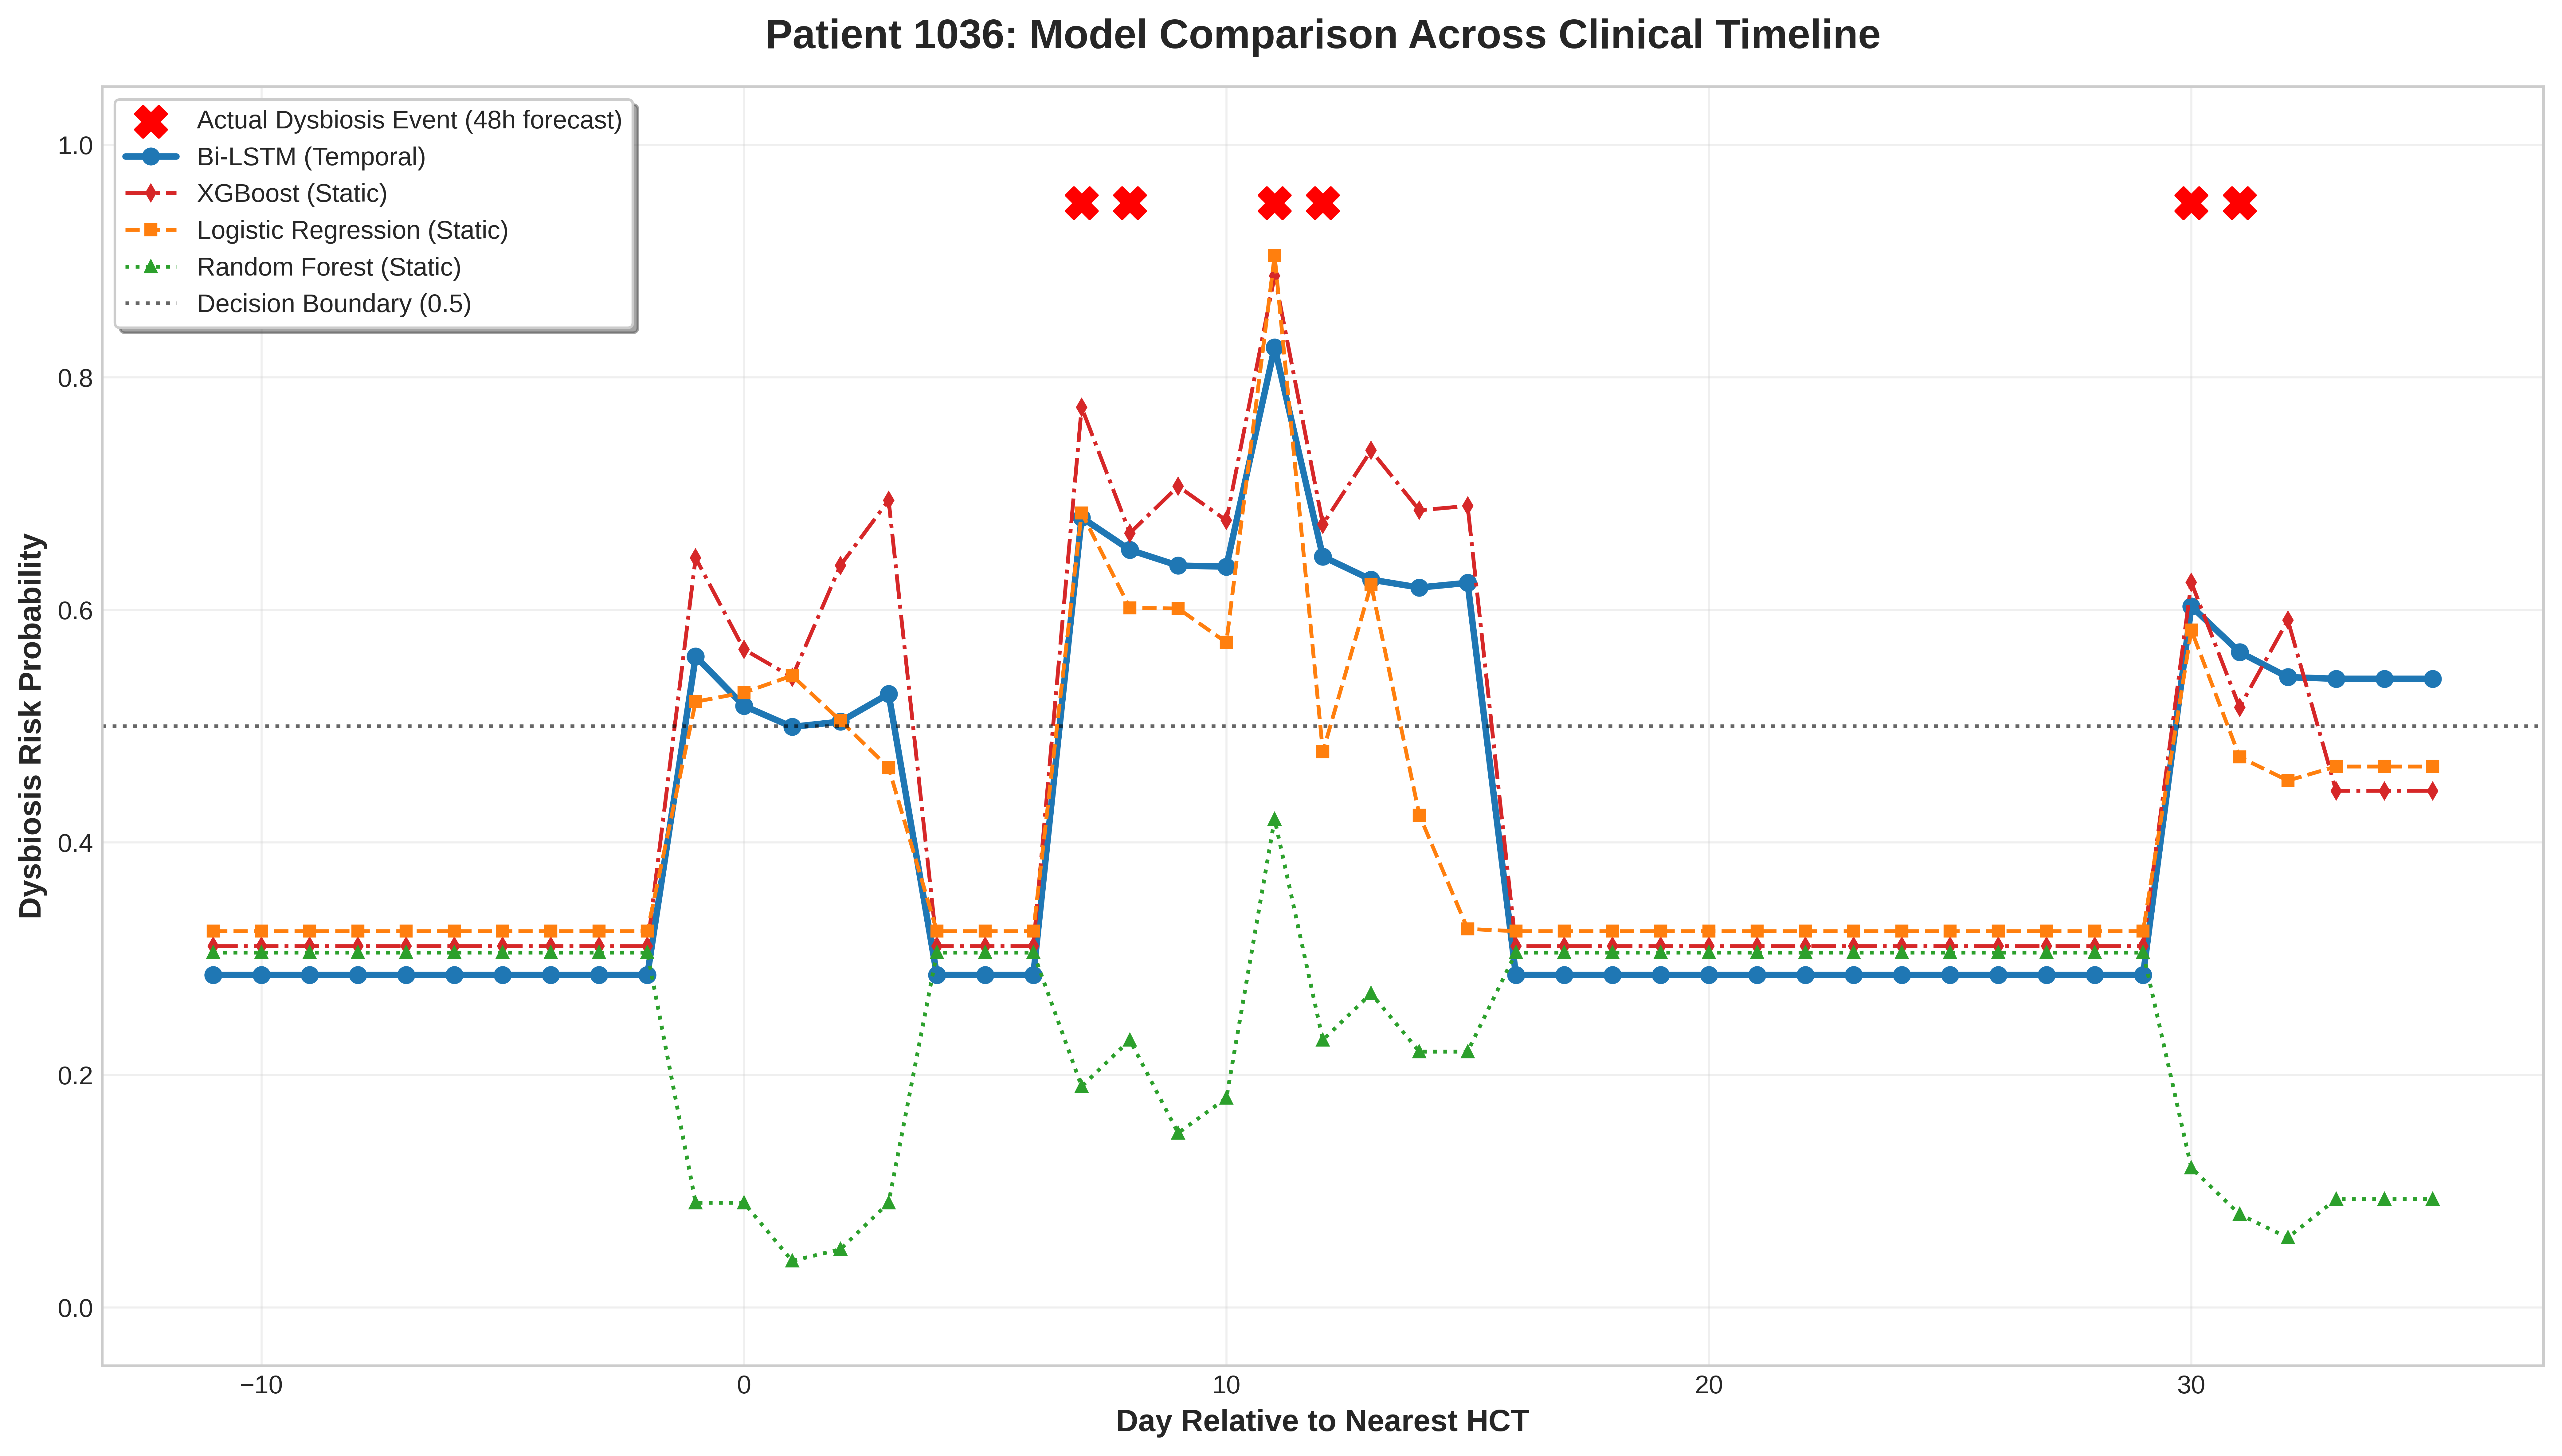

In [22]:
#@title 16. Patient Case Study
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- Individual Patient Trajectory with Predictions ---

# 1. Dynamically select a patient with sufficient data for sequence generation
#    Preferably a patient with a dysbiosis event if available, otherwise any patient with data.
OBS_LEN_CURRENT = OBS_LEN # Ensure OBS_LEN is used from global scope
TARGET_LEN_CURRENT = TARGET_LEN # Ensure TARGET_LEN is used from global scope

possible_patients = df_test['PatientID'].unique()
patient_with_dysbiosis_test = None

if len(possible_patients) > 0:
    for pid in possible_patients:
        temp_patient_df = df_test[df_test['PatientID'] == pid].sort_values('DayRelativeToNearestHCT').reset_index(drop=True)
        # Check if there is enough data to build at least one sequence
        if len(temp_patient_df) >= (OBS_LEN_CURRENT + TARGET_LEN_CURRENT):
            # Check if this patient has any positive dysbiosis events in their generated sequences
            _, y_patient_check = build_benchmark_sequences(temp_patient_df, active_features, scaler, fit_scaler=False, obs_len=OBS_LEN_CURRENT, target_len=TARGET_LEN_CURRENT)
            if np.any(y_patient_check == 1):
                patient_with_dysbiosis_test = pid
                break
    # Fallback: if no patient with dysbiosis found, just pick the first one with enough data
    if patient_with_dysbiosis_test is None:
        for pid in possible_patients:
            temp_patient_df = df_test[df_test['PatientID'] == pid].sort_values('DayRelativeToNearestHCT').reset_index(drop=True)
            if len(temp_patient_df) >= (OBS_LEN_CURRENT + TARGET_LEN_CURRENT):
                patient_with_dysbiosis_test = pid
                break

if patient_with_dysbiosis_test is None:
    print("Error: No suitable patient found in df_test with enough data to generate sequences.")
    # Exit or handle gracefully if no patient can be found
else:
    print(f"Generating All-Models Trajectory Plot for Patient: {patient_with_dysbiosis_test}")

    # 2. Extract data for this patient from the original df_test
    patient_df = df_test[df_test['PatientID'] == patient_with_dysbiosis_test].sort_values('DayRelativeToNearestHCT').reset_index(drop=True)

    # 3. Re-generate sequences for this specific patient for prediction
    X_patient, y_patient = build_benchmark_sequences(patient_df, active_features, scaler, fit_scaler=False, obs_len=OBS_LEN_CURRENT, target_len=TARGET_LEN_CURRENT)

    # Check if X_patient is still empty (e.g., if there was an edge case not caught)
    if X_patient.shape[0] == 0:
        print(f"Warning: No sequences could be generated for Patient {patient_with_dysbiosis_test}. Skipping plot.")
    else:
        # 4. Get predictions for this patient's sequences from all models
        patient_pred_probs_bilstm = baseline_model.predict(X_patient).ravel()

        # Flatten X_patient for static models
        X_patient_flat = X_patient.reshape(X_patient.shape[0], -1)
        patient_pred_probs_lr = lr_model.predict_proba(X_patient_flat)[:, 1]
        patient_pred_probs_rf = rf_model.predict_proba(X_patient_flat)[:, 1]
        patient_pred_probs_xgb = xgb_model.predict_proba(X_patient_flat)[:, 1]

        # 5. Align predictions with the clinical timeline
        # The prediction corresponds to the end of the observation window. The target label is for TARGET_LEN days after this.
        all_days = patient_df['DayRelativeToNearestHCT'].values

        plot_data = pd.DataFrame({
            'DayRelativeToNearestHCT': all_days,
            'Actual_Dysbiosis_Label': patient_df['Dysbiosis_Label'].values
        })

        # Create temporary columns for merging predictions
        plot_data['Predicted_Probability_BiLSTM_temp'] = np.nan
        plot_data['Predicted_Probability_LR_temp'] = np.nan
        plot_data['Predicted_Probability_RF_temp'] = np.nan
        plot_data['Predicted_Probability_XGB_temp'] = np.nan

        # Align predictions to the day the prediction 'ends' (OBS_LEN-1 day of the sequence)
        prediction_days = patient_df['DayRelativeToNearestHCT'].iloc[OBS_LEN_CURRENT - 1 : OBS_LEN_CURRENT - 1 + len(patient_pred_probs_bilstm)].values

        for i, day in enumerate(prediction_days):
            plot_data.loc[plot_data['DayRelativeToNearestHCT'] == day, 'Predicted_Probability_BiLSTM_temp'] = patient_pred_probs_bilstm[i]
            plot_data.loc[plot_data['DayRelativeToNearestHCT'] == day, 'Predicted_Probability_LR_temp'] = patient_pred_probs_lr[i]
            plot_data.loc[plot_data['DayRelativeToNearestHCT'] == day, 'Predicted_Probability_RF_temp'] = patient_pred_probs_rf[i]
            plot_data.loc[plot_data['DayRelativeToNearestHCT'] == day, 'Predicted_Probability_XGB_temp'] = patient_pred_probs_xgb[i]

        # Fill forward the predictions so they are visible over the forecast horizon
        plot_data['Predicted_Probability_BiLSTM'] = plot_data['Predicted_Probability_BiLSTM_temp'].ffill()
        plot_data['Predicted_Probability_LR'] = plot_data['Predicted_Probability_LR_temp'].ffill()
        plot_data['Predicted_Probability_RF'] = plot_data['Predicted_Probability_RF_temp'].ffill()
        plot_data['Predicted_Probability_XGB'] = plot_data['Predicted_Probability_XGB_temp'].ffill()


        # --- Plotting ---
        plt.figure(figsize=(14, 8), dpi=600)

        # Plot Actual Dysbiosis Events (shifted by TARGET_LEN to represent target labels)
        # For plotting actual labels, we need to align y_patient to the day it corresponds to.
        # y_patient is the label for TARGET_LEN days *after* the observation window.
        # The prediction_days represent the last day of the OBS_LEN window.
        # So, the actual dysbiosis event should be plotted from prediction_days + TARGET_LEN

        # Create a DataFrame for actual events based on y_patient for correct alignment
        actual_events_df = pd.DataFrame({
            'DayRelativeToNearestHCT_EndObs': prediction_days,
            'Actual_Label_Sequence': y_patient
        })
        actual_events_df['DayOfDysbiosis'] = actual_events_df['DayRelativeToNearestHCT_EndObs'] + TARGET_LEN_CURRENT

        dysbiosis_events_for_plot = actual_events_df[actual_events_df['Actual_Label_Sequence'] == 1]

        if not dysbiosis_events_for_plot.empty:
            plt.scatter(dysbiosis_events_for_plot['DayOfDysbiosis'], np.ones(len(dysbiosis_events_for_plot)) * 0.95, # Plot slightly below 1 for visibility
                        color='red', marker='X', s=150, label='Actual Dysbiosis Event (48h forecast)', zorder=5)

        # Plot Predicted Probabilities
        plt.plot(plot_data['DayRelativeToNearestHCT'], plot_data['Predicted_Probability_BiLSTM'],
                 color='#1f77b4', linestyle='-', marker='o', markersize=6, linewidth=2.5, label='Bi-LSTM (Temporal)', zorder=2)
        plt.plot(plot_data['DayRelativeToNearestHCT'], plot_data['Predicted_Probability_XGB'],
                 color='#d62728', linestyle='-.', marker='d', markersize=4, label='XGBoost (Static)', zorder=2)
        plt.plot(plot_data['DayRelativeToNearestHCT'], plot_data['Predicted_Probability_LR'],
                 color='#ff7f0e', linestyle='--', marker='s', markersize=4, label='Logistic Regression (Static)', zorder=2)
        plt.plot(plot_data['DayRelativeToNearestHCT'], plot_data['Predicted_Probability_RF'],
                 color='#2ca02c', linestyle=':', marker='^', markersize=4, label='Random Forest (Static)', zorder=2)

        plt.axhline(0.5, color='black', linestyle=':', alpha=0.6, label='Decision Boundary (0.5)')

        plt.title(f'Patient {patient_with_dysbiosis_test}: Model Comparison Across Clinical Timeline', fontsize=16, fontweight='bold', pad=15)
        plt.xlabel('Day Relative to Nearest HCT', fontsize=12, fontweight='bold')
        plt.ylabel('Dysbiosis Risk Probability', fontsize=12, fontweight='bold')
        plt.ylim([-0.05, 1.05])
        plt.legend(loc='upper left', fontsize=10, frameon=True, shadow=True)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

        plt.savefig(f'Figure_Patient_{patient_with_dysbiosis_test}_Model_Comparison.pdf', format='pdf', dpi=600)
        print(f"Saved comparison plot to 'Figure_Patient_{patient_with_dysbiosis_test}_Model_Comparison.pdf'.")
        plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
High-resolution figure saved for Patient 1036.


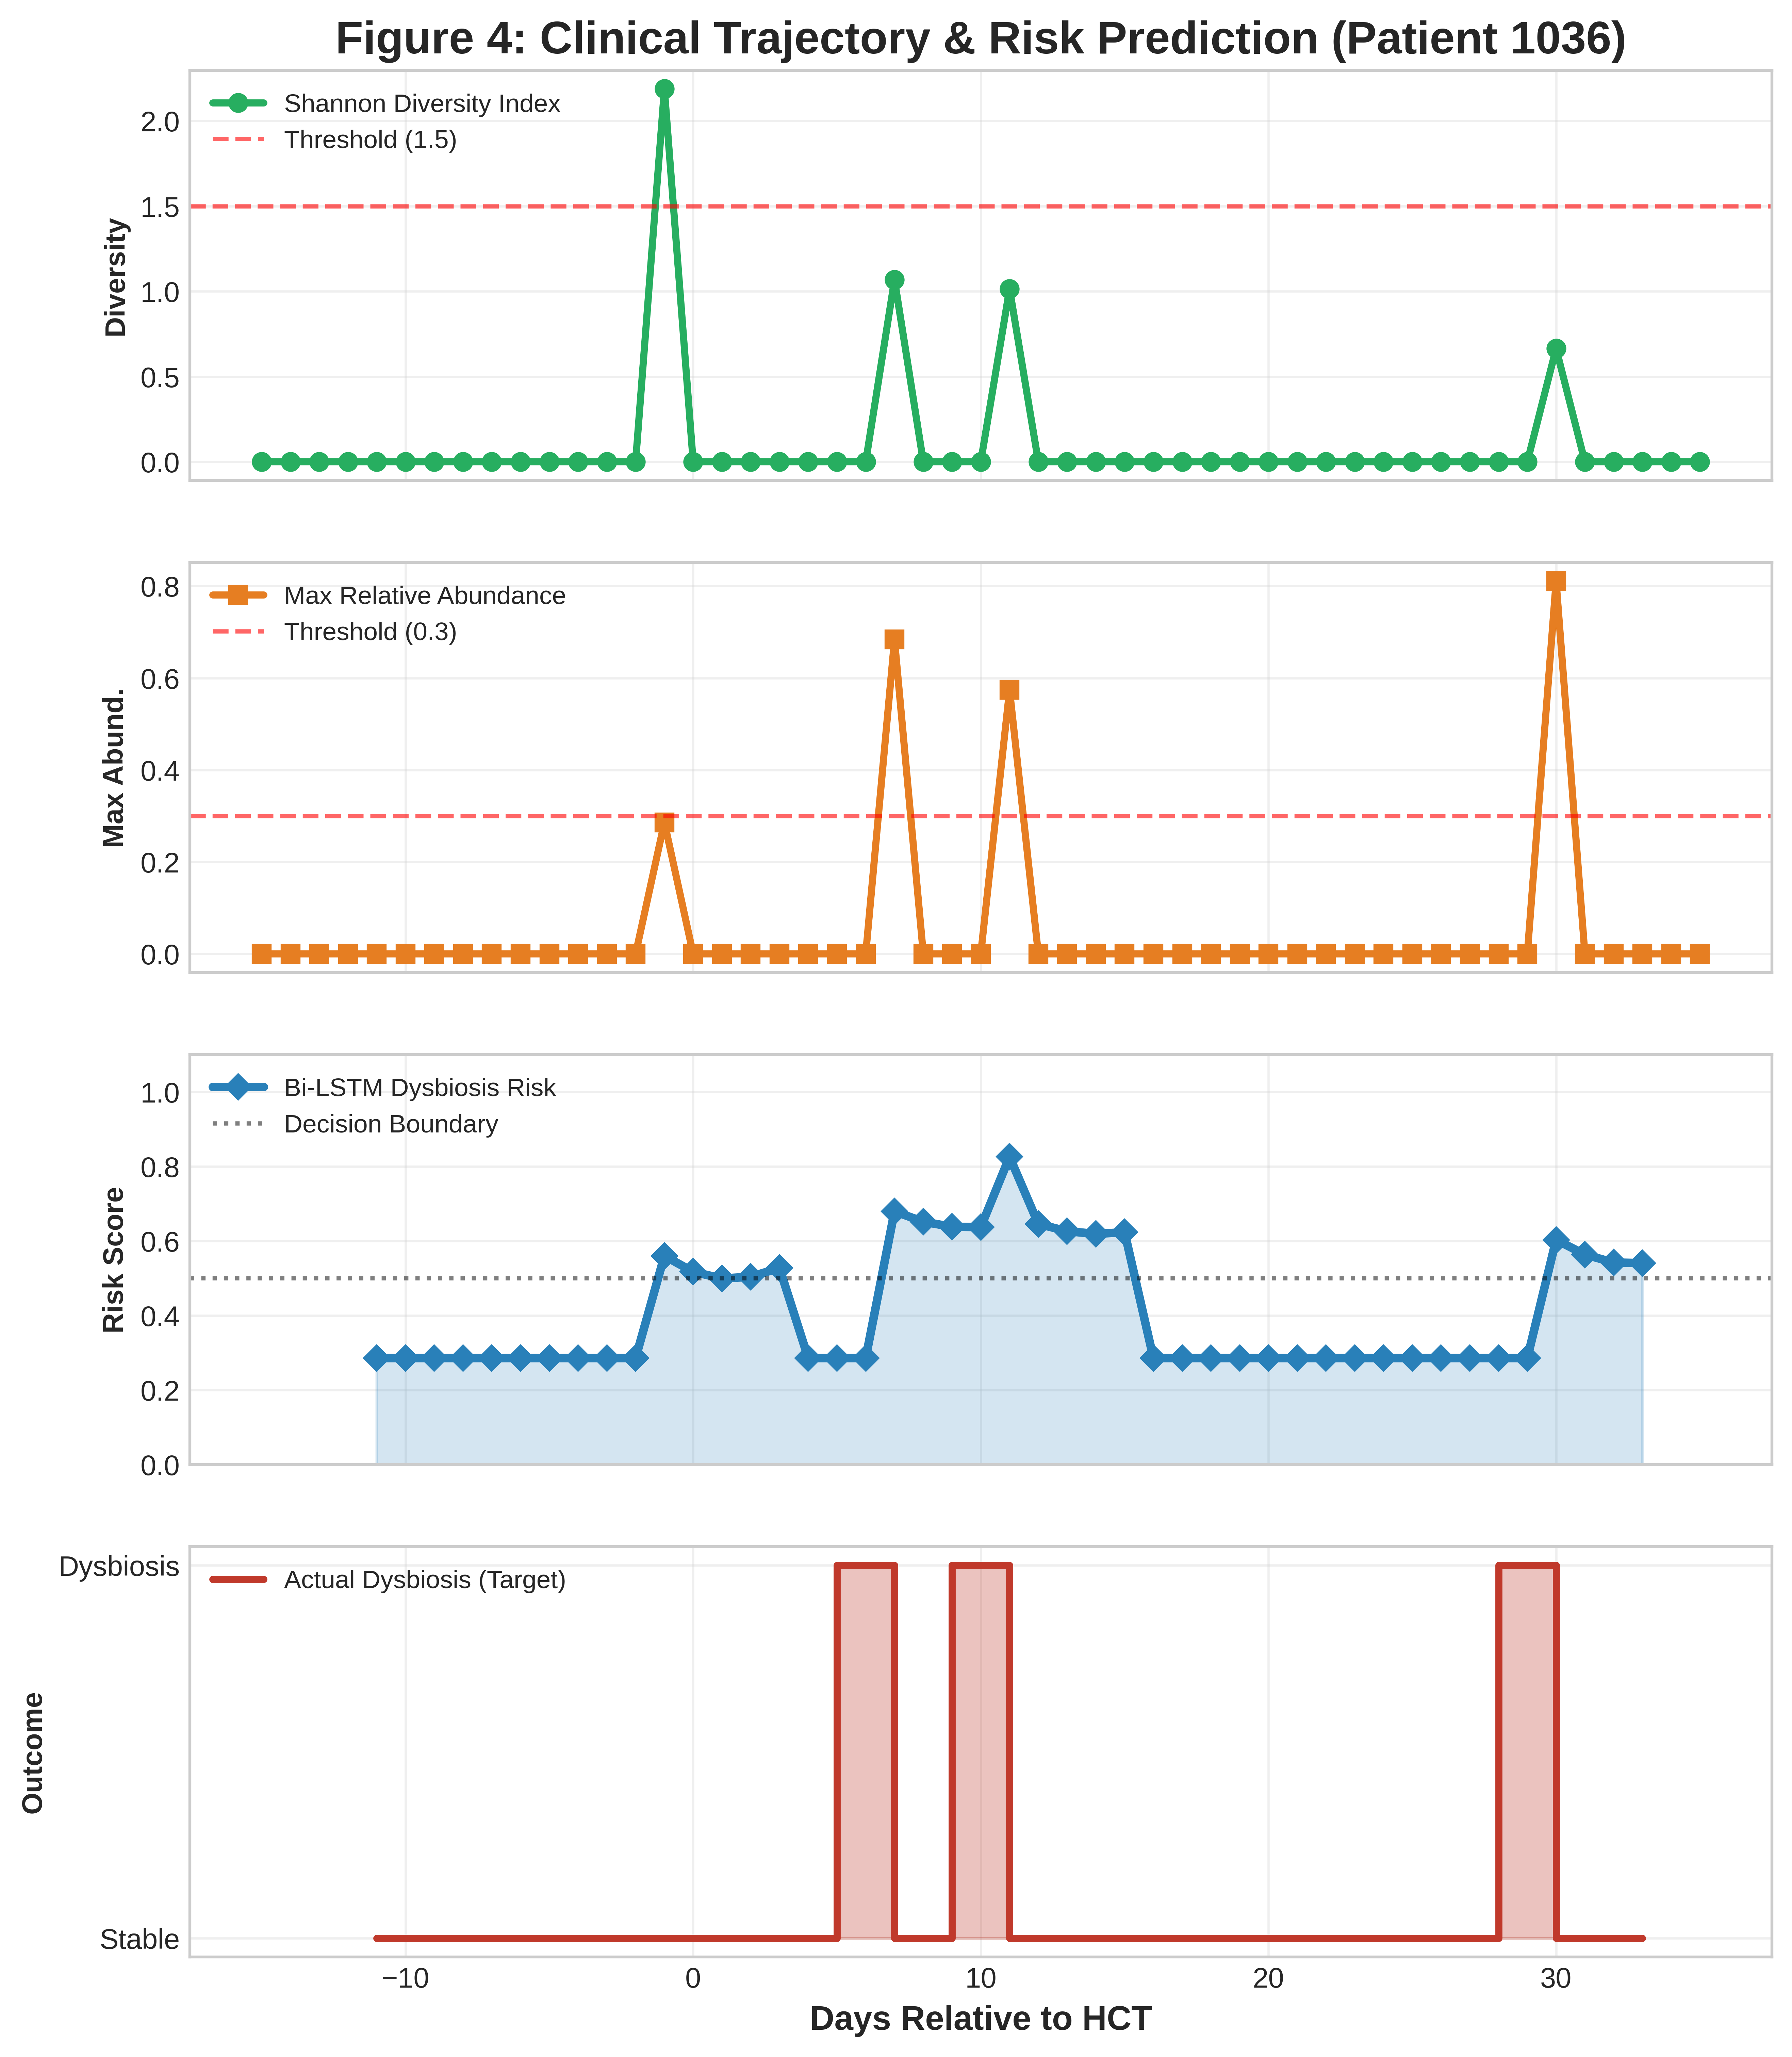

In [23]:
#@title 17 Find a patient in the test set with at least one POSITIVE dysbiosis event
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import entropy

# 1. Improved search: Find a patient in the test set with at least one POSITIVE dysbiosis event
df_test_copy = df_test.copy()

def get_metrics(row):
    vals = row[active_features].values.astype(float)
    total = vals.sum()
    if total == 0: return 0, 0
    rel = vals / total
    return rel.max(), entropy(rel)

df_test_copy[['Domination', 'Diversity']] = df_test_copy.apply(
    lambda r: pd.Series(get_metrics(r)), axis=1
)

# Find patients with a label of 1 in the target sequences (Y labels)
positive_patients = []
for pid, group in df_test.groupby('PatientID'):
    _, y_p = build_benchmark_sequences(group, active_features, scaler, fit_scaler=False)
    if np.any(y_p == 1):
        positive_patients.append(pid)

# Select a patient that has a clear transition if possible
selected_pid = positive_patients[0] if positive_patients else df_test['PatientID'].unique()[0]

# 2. Prepare Plotting Data
pat_data = df_test_copy[df_test_copy['PatientID'] == selected_pid].sort_values('DayRelativeToNearestHCT')
X_p, y_p_actual = build_benchmark_sequences(pat_data, active_features, scaler, fit_scaler=False)
risk_scores = baseline_model.predict(X_p).ravel()

# Alignment: plot_days matches the prediction timing (end of obs window)
days = pat_data['DayRelativeToNearestHCT'].values
plot_days = days[OBS_LEN-1 : OBS_LEN-1 + len(risk_scores)]

# 3. Create the 4-Panel Trajectory Plot
fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True, dpi=600)
plt.subplots_adjust(hspace=0.2)

# Panel 1: Shannon Diversity
axes[0].plot(days, pat_data['Diversity'], color='#27ae60', lw=2.5, marker='o', label='Shannon Diversity Index')
axes[0].axhline(1.5, color='red', linestyle='--', alpha=0.6, label='Threshold (1.5)')
axes[0].set_ylabel('Diversity', fontweight='bold')
axes[0].set_title(f'Figure 4: Clinical Trajectory & Risk Prediction (Patient {selected_pid})', fontsize=16, fontweight='bold')

# Panel 2: Pathogen Domination
axes[1].plot(days, pat_data['Domination'], color='#e67e22', lw=2.5, marker='s', label='Max Relative Abundance')
axes[1].axhline(0.3, color='red', linestyle='--', alpha=0.6, label='Threshold (0.3)')
axes[1].set_ylabel('Max Abund.', fontweight='bold')

# Panel 3: Risk Score (Model Output)
axes[2].plot(plot_days, risk_scores, color='#2980b9', lw=3, marker='D', label='Bi-LSTM Dysbiosis Risk')
axes[2].fill_between(plot_days, 0, risk_scores, color='#2980b9', alpha=0.2)
axes[2].axhline(0.5, color='black', linestyle=':', alpha=0.5, label='Decision Boundary')
axes[2].set_ylabel('Risk Score', fontweight='bold')
axes[2].set_ylim(0, 1.1)

# Panel 4: Actual Dysbiosis Label (48h Horizon)
axes[3].step(plot_days, y_p_actual, where='post', color='#c0392b', lw=2.5, label='Actual Dysbiosis (Target)')
axes[3].fill_between(plot_days, 0, y_p_actual, step='post', color='#c0392b', alpha=0.3)
axes[3].set_ylabel('Outcome', fontweight='bold')
axes[3].set_yticks([0, 1])
axes[3].set_yticklabels(['Stable', 'Dysbiosis'])

plt.xlabel('Days Relative to HCT', fontsize=12, fontweight='bold')

for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left', fontsize=9)

plt.savefig('Figure_4_Patient_Trajectory.pdf', format='pdf', bbox_inches='tight')
print(f"High-resolution figure saved for Patient {selected_pid}.")
plt.show()

In [24]:
#@title 18 Bootstrap Testing
from sklearn.metrics import average_precision_score, roc_auc_score
import numpy as np
import pandas as pd

# Ensure y_test is a 1D array
y_test_1d = y_test.ravel()

def bootstrap_metrics(y_true, y_pred_proba, n_iterations=1000, alpha=0.95, seed=42):
    """
    Performs bootstrap resampling to estimate confidence intervals for AUPRC and AUROC.
    """
    # 1. Lock the seed for paper reproducibility
    np.random.seed(seed)

    n_samples = len(y_true)
    auprc_scores = []
    auroc_scores = []

    # 2. Calculate the EXACT original scores for the paper
    orig_auprc = average_precision_score(y_true, y_pred_proba)
    orig_auroc = roc_auc_score(y_true, y_pred_proba)

    # 3. Use a while loop to guarantee EXACTLY 1000 valid iterations
    while len(auprc_scores) < n_iterations:
        # Sample with replacement
        indices = np.random.choice(n_samples, n_samples, replace=True)
        y_true_sample = y_true[indices]
        y_pred_proba_sample = y_pred_proba[indices]

        # Calculate metrics only if there's at least one positive and one negative class
        if len(np.unique(y_true_sample)) == 2:
            auprc_scores.append(average_precision_score(y_true_sample, y_pred_proba_sample))
            auroc_scores.append(roc_auc_score(y_true_sample, y_pred_proba_sample))

    # Calculate confidence intervals (e.g., 2.5th and 97.5th percentiles for 95% CI)
    lower_percentile = (1 - alpha) / 2 * 100
    upper_percentile = (1 + alpha) / 2 * 100

    results = {
        'auprc_exact': orig_auprc,
        'auprc_ci_lower': np.percentile(auprc_scores, lower_percentile),
        'auprc_ci_upper': np.percentile(auprc_scores, upper_percentile),
        'auroc_exact': orig_auroc,
        'auroc_ci_lower': np.percentile(auroc_scores, lower_percentile),
        'auroc_ci_upper': np.percentile(auroc_scores, upper_percentile)
    }
    return results

n_bootstrap_iterations = 1000
confidence_level = 0.95

print(f"Performing rigorous bootstrap evaluation with {n_bootstrap_iterations} iterations...\n")

# --- Bi-LSTM Model ---
print("Calculating Bi-LSTM Bootstrap CIs...")
bilstm_results = bootstrap_metrics(y_test_1d, y_pred_probs)
print(f"Bi-LSTM AUPRC: {bilstm_results['auprc_exact']:.4f} ({bilstm_results['auprc_ci_lower']:.4f} - {bilstm_results['auprc_ci_upper']:.4f})")
print(f"Bi-LSTM AUROC: {bilstm_results['auroc_exact']:.4f} ({bilstm_results['auroc_ci_lower']:.4f} - {bilstm_results['auroc_ci_upper']:.4f})\n")

# --- Logistic Regression Model ---
print("Calculating Logistic Regression Bootstrap CIs...")
lr_results = bootstrap_metrics(y_test_1d, lr_probs)
print(f"LR AUPRC: {lr_results['auprc_exact']:.4f} ({lr_results['auprc_ci_lower']:.4f} - {lr_results['auprc_ci_upper']:.4f})")
print(f"LR AUROC: {lr_results['auroc_exact']:.4f} ({lr_results['auroc_ci_lower']:.4f} - {lr_results['auroc_ci_upper']:.4f})\n")

# --- Random Forest Model ---
print("Calculating Random Forest Bootstrap CIs...")
rf_results = bootstrap_metrics(y_test_1d, rf_probs)
print(f"RF AUPRC: {rf_results['auprc_exact']:.4f} ({rf_results['auprc_ci_lower']:.4f} - {rf_results['auprc_ci_upper']:.4f})")
print(f"RF AUROC: {rf_results['auroc_exact']:.4f} ({rf_results['auroc_ci_lower']:.4f} - {rf_results['auroc_ci_upper']:.4f})\n")

# --- XGBoost Model ---
print("Calculating XGBoost Bootstrap CIs...")
xgb_results = bootstrap_metrics(y_test_1d, xgb_probs)
print(f"XGBoost AUPRC: {xgb_results['auprc_exact']:.4f} ({xgb_results['auprc_ci_lower']:.4f} - {xgb_results['auprc_ci_upper']:.4f})")
print(f"XGBoost AUROC: {xgb_results['auroc_exact']:.4f} ({xgb_results['auroc_ci_lower']:.4f} - {xgb_results['auroc_ci_upper']:.4f})\n")

Performing rigorous bootstrap evaluation with 1000 iterations...

Calculating Bi-LSTM Bootstrap CIs...
Bi-LSTM AUPRC: 0.3224 (0.2964 - 0.3490)
Bi-LSTM AUROC: 0.7577 (0.7418 - 0.7720)

Calculating Logistic Regression Bootstrap CIs...
LR AUPRC: 0.3151 (0.2895 - 0.3425)
LR AUROC: 0.7534 (0.7376 - 0.7680)

Calculating Random Forest Bootstrap CIs...
RF AUPRC: 0.2048 (0.1821 - 0.2299)
RF AUROC: 0.5182 (0.4986 - 0.5372)

Calculating XGBoost Bootstrap CIs...
XGBoost AUPRC: 0.3226 (0.2956 - 0.3512)
XGBoost AUROC: 0.7543 (0.7387 - 0.7688)

